# MAISON-LLF Clinical Outcome Prediction

**Mahmoud Z A Nijim**  
Blekinge Institute of Technology

This notebook implements a leakage-safe supervised regression workflow for predicting clinical outcome scores from MAISON-LLF data. The workflow includes rolling-window feature enrichment, Leave-One-Participant-Out cross-validation, absolute-score prediction, delta-target analysis, model comparison, Friedman statistical testing, and exploratory SHAP interpretation.

## Expected input files

Place the following files in the `data/` folder before running the notebook:

- `maison-llf-features.csv`
- `maison-llf-demographics.csv`
- `maison-llf-feature-descriptions.xlsx`

## Notebook structure

1. Project overview and data loading
2. Leakage-safe preprocessing
3. Rolling-window feature enrichment
4. LOPO-CV modelling
5. Absolute-score prediction
6. Delta-target analysis
7. Friedman statistical testing
8. Exploratory SHAP interpretation
9. Saved outputs


## Project overview

The goal of this project is to predict three clinical outcome scores from wearable sensor data:

- **SIS**
- **OHS**
- **OKS**

This is a regression problem, and the main challenge is generalizing to a participant not seen during training. To handle that, Leave-One-Participant-Out cross-validation is used throughout the project.

### Success criteria

A useful model should:
1. be compared against a leakage-safe Naive Mean baseline,
2. be evaluated under strict unseen-participant validation,
3. remain interpretable.

MAE is used as the main metric because it is easier to interpret than \(R^2\) in this LOPO setting.


---
## Imports, paths, and setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import importlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from scipy.stats import friedmanchisquare
import lightgbm as lgb
import shap

SEED = 42
np.random.seed(SEED)

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
OUTPUTS_DIR = ROOT / 'outputs'
TABLES_DIR = OUTPUTS_DIR / 'tables'
FIGURES_DIR = OUTPUTS_DIR / 'figures'

for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

pkgs = ['numpy', 'pandas', 'sklearn', 'lightgbm', 'shap', 'matplotlib', 'scipy']
print(f"Python : {sys.version.split()[0]}")
for p in pkgs:
    m = importlib.import_module(p)
    print(f"  {p:<12}: {getattr(m, '__version__', '?')}")
print(f"  SEED        : {SEED}")

Python : 3.11.15
  numpy       : 2.4.6
  pandas      : 3.0.3
  sklearn     : 1.9.0
  lightgbm    : 4.6.0
  shap        : 0.51.0
  matplotlib  : 3.10.9
  scipy       : 1.17.1
  SEED        : 42


---
## Phase 2 — Data Understanding

The dataset has three main files:
- daily sensor features
- participant demographics
- feature descriptions

Next I load them and check that they match correctly.

### Relation to previous work

Previous work has shown that wearable data can be useful for monitoring activity and recovery.  
In this project I focus on strict participant-level evaluation, leakage prevention, and comparing several regression models on SIS, OHS, and OKS.

In [2]:
# Load the three main data files
df_raw       = pd.read_csv(DATA_DIR / 'maison-llf-features.csv')
df_demo      = pd.read_csv(DATA_DIR / 'maison-llf-demographics.csv')
df_feat_desc = pd.read_excel(DATA_DIR / 'maison-llf-feature-descriptions.xlsx')

# Convert timestamp to datetime for sorting and rolling features later
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

print("=== Files loaded ===")
print(f"  features.csv       : {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")
print(f"  demographics.csv   : {df_demo.shape[0]} rows x {df_demo.shape[1]} cols")
print(f"  feature-desc.xlsx  : {df_feat_desc.shape[0]} rows x {df_feat_desc.shape[1]} cols")
print()

df_raw.head(2)

=== Files loaded ===
  features.csv       : 1008 rows x 84 cols
  demographics.csv   : 18 rows x 8 cols
  feature-desc.xlsx  : 22 rows x 3 cols



,participant,timestamp,clinical-timestamp,sis-01,sis-02,sis-03,sis-04,sis-05,sis-06,sis,...,sleep-duration-to-wakeup,sleep-wakeup-count,sleep-heartrate-mean,sleep-heartrate-min,sleep-heartrate-max,step-count,step-ratio,step-mean,step-max,step-max-timestamp
0,1,2022-03-31,2022-04-13,5,5,4,4,5,2,25,...,0.0,3,59,54,74,415,0.5000,34.5833,106,13
1,1,2022-04-01,2022-04-13,5,5,4,4,5,2,25,...,0.0,4,61,56,82,447,0.2917,63.8571,185,8


In [3]:
# Show a few rows from the feature description file
display(df_feat_desc.head())

,data modality- 1,feature 1,Description
0,acceleration-,"count, entropy, kurtosis, mean, skew, std, and...","The total count, entropy, kurtosis, mean, skew..."
1,NaN,coefficient-of-variation,Measures the relative variability of daily phy...
2,NaN,minutes-with-data,Represents the total number of minutes within ...
3,NaN,hours-with-data,Represents the total number of hours within a ...
4,NaN,"movement-events-00to06, movement-events-06to12...",Represents the number of detected movement eve...


### Merge demographics

Demographics are stored as one row per participant, so I merge them using the `participant` column.

This merged table is mainly for checking and feature construction.  
During modelling, encoding is still done inside each LOPO fold to avoid leakage.

In [4]:
# Merge demographics into the feature table
# Keep df_raw unchanged and use df_merged only for checking at this stage
df_merged = df_raw.merge(df_demo, on='participant', how='left')

# Check that the merge worked as expected
demo_cols = [c for c in df_demo.columns if c != 'participant']

assert df_merged.shape[0] == df_raw.shape[0], \
    f"Row count changed after merge: {df_raw.shape[0]} -> {df_merged.shape[0]}"
assert df_merged.shape[1] == df_raw.shape[1] + len(demo_cols), \
    f"Unexpected column count after merge"

missing_after_merge = df_merged[demo_cols].isna().sum().sum()
assert missing_after_merge == 0, \
    f"Missing demographics after merge ({missing_after_merge} NaNs) — participant ID mismatch?"

feat_pids = set(df_raw['participant'].unique())
demo_pids = set(df_demo['participant'].unique())
assert feat_pids == demo_pids, \
    f"Participant ID mismatch: in-features-not-demo={feat_pids-demo_pids}"

print("=== Merge result ===")
print(f"  df_raw shape    : {df_raw.shape}")
print(f"  df_merged shape : {df_merged.shape}  (+{len(demo_cols)} demographic columns)")
print(f"  Demographic cols: {demo_cols}")
print()
print("[OK] Merge valid: row count preserved, no missing demographics, participant IDs match")
print()
df_demo


=== Merge result ===
  df_raw shape    : (1008, 84)
  df_merged shape : (1008, 91)  (+7 demographic columns)
  Demographic cols: ['sex', 'age', 'fracture-type', 'relationship', 'education', 'work', 'ethnicity']

[OK] Merge valid: row count preserved, no missing demographics, participant IDs match



,participant,sex,age,fracture-type,relationship,education,work,ethnicity
0,1,female,74,hip fracture,widowed,undergraduate degree,retired,black
1,2,female,66,hip fracture,separated,undergraduate degree,employed part-time,caucasian
2,3,female,70,pelvis fracture,single,secondary education,retired,caucasian
3,4,female,60,femur fracture,divorced,secondary education,retired,caucasian
4,5,male,75,hip replacement,single,doctorate degree,employed part-time,caucasian
5,6,female,85,pelvis fracture,single,undergraduate degree,employed part-time,caucasian
6,7,female,78,hip replacement,divorced,graduate degree,retired,caucasian
7,8,female,89,hip replacement,single,secondary education,retired,caucasian
8,9,female,74,hip fracture,divorced,doctorate degree,retired,caucasian
9,10,male,77,hip replacement,widowed,secondary education,retired,caucasian


### Basic data checks

Here I check:
- shape
- missing values
- duplicate keys
- participant balance
- target ranges

If something important is wrong, the cell will stop with an `AssertionError`.

In [5]:
print("=" * 60)
print("BASIC DATA CHECKS")
print("=" * 60)

# 1. Shape
print("\n--- Shape ---")
n_participants = df_raw['participant'].nunique()
rows_per_part  = df_raw.shape[0] // n_participants
print(f"  features  : {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")
print(f"              {n_participants} participants x {rows_per_part} days per participant")
print(f"  demo      : {df_demo.shape[0]} rows x {df_demo.shape[1]} cols")
print(f"  feat_desc : {df_feat_desc.shape[0]} rows x {df_feat_desc.shape[1]} cols")

assert df_raw.shape[0] == n_participants * rows_per_part, "Uneven rows per participant"

# 2. Missing values
print("\n--- Missingness ---")
feat_null_total = df_raw.isna().sum().sum()
demo_null_total = df_demo.isna().sum().sum()
print(f"  features.csv  : {feat_null_total} total NaN values")
print(f"  demographics  : {demo_null_total} total NaN values")

feat_null_cols = df_raw.columns[df_raw.isna().any()].tolist()
if feat_null_cols:
    print(f"  [WARN] Columns with nulls in features: {feat_null_cols}")
    print(df_raw[feat_null_cols].isna().sum().to_string())
else:
    print("  [OK] No missing values in features")

demo_null_cols = df_demo.columns[df_demo.isna().any()].tolist()
if demo_null_cols:
    print(f"  [WARN] Columns with nulls in demographics: {demo_null_cols}")
else:
    print("  [OK] No missing values in demographics")

# 3. Duplicates
print("\n--- Duplicate Keys ---")
dup_full = df_raw.duplicated().sum()
dup_key  = df_raw.duplicated(subset=['participant', 'timestamp']).sum()
dup_demo = df_demo.duplicated(subset=['participant']).sum()
print(f"  features full-row duplicates           : {dup_full}")
print(f"  features (participant, timestamp) dupes: {dup_key}")
print(f"  demographics participant duplicates    : {dup_demo}")

assert dup_key  == 0, f"Duplicate (participant, timestamp) keys: {dup_key}"
assert dup_demo == 0, f"Duplicate participant rows in demographics: {dup_demo}"
print("  [OK] No duplicate keys")

# 4. Participant balance
print("\n--- Participant Balance ---")
rows_by_part = df_raw.groupby('participant').size()
print(f"  Participants: {sorted(df_raw['participant'].unique())}")
print(f"  Rows per participant: min={rows_by_part.min()}, max={rows_by_part.max()}, "
      f"all equal={rows_by_part.nunique()==1}")
assert rows_by_part.nunique() == 1, \
    f"Participants have unequal row counts: {rows_by_part.to_dict()}"
print("  [OK] All participants have equal row count")

# 5. Timestamp ordering
print("\n--- Timestamp Coverage ---")
print(f"  Global date range: {df_raw['timestamp'].min().date()} to {df_raw['timestamp'].max().date()}")
dup_ts = df_raw.groupby('participant')['timestamp'].apply(lambda x: x.duplicated().sum())
assert dup_ts.sum() == 0, f"Duplicate timestamps within participants: {dup_ts[dup_ts>0]}"
print("  [OK] No duplicate timestamps within any participant")

# 6. Target ranges
print("\n--- Target Distributions ---")
for t in ['sis', 'ohs']:
    s = df_raw[t]
    print(f"  {t}: min={s.min():4} max={s.max():4} mean={s.mean():.2f} "
          f"std={s.std():.2f} nulls={s.isna().sum()}")

print()
print("=" * 60)
print("ALL BASIC CHECKS PASSED")
print("=" * 60)

BASIC DATA CHECKS

--- Shape ---
  features  : 1008 rows x 84 cols
              18 participants x 56 days per participant
  demo      : 18 rows x 8 cols
  feat_desc : 22 rows x 3 cols

--- Missingness ---
  features.csv  : 0 total NaN values
  demographics  : 0 total NaN values
  [OK] No missing values in features
  [OK] No missing values in demographics

--- Duplicate Keys ---
  features full-row duplicates           : 0
  features (participant, timestamp) dupes: 0
  demographics participant duplicates    : 0
  [OK] No duplicate keys

--- Participant Balance ---
  Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
  Rows per participant: min=56, max=56, all equal=True
  [OK] All participants have equal row count

--- Timestamp Coverage ---
  Global date range: 2022-03-31 to 2025-1

### Data summary

Main points from the dataset:
- 18 participants
- 56 days per participant
- 1,008 total rows
- 46 raw sensor features
- 7 demographic features

A key issue is participant mean-shift, which makes absolute prediction difficult under LOPO-CV.

I also found a small number of within-block target inconsistencies for a few participants, which are fixed later using block-median aggregation.

## Data preparation and leakage-safe preprocessing

### Leakage removal

Before modelling, columns that would let the model indirectly see the answer are removed.

These include:
- SIS, OHS, and OKS questionnaire sub-items
- same-day clinical test variables
- `clinical-timestamp` as a predictor

All preprocessing is fit inside each LOPO fold, so the held-out participant never affects scaling, imputation, or encoding.

### Preprocessing

Inside each LOPO fold:
- numeric columns are imputed with the median and scaled with `RobustScaler`
- categorical demographics are imputed and ordinal-encoded
- all transformers are fit on training participants only

This keeps the pipeline leakage-safe.

### Feature selection

No separate feature-selection step is used.

Instead:
- ElasticNet gives implicit selection through L1 regularization
- LightGBM selects useful splits automatically
- SHAP is used later to inspect important features

### Rolling-window features

To capture short-term trends, rolling features are computed over 3-, 7-, and 14-day windows.

For each sensor feature, the following summaries are added:
- mean
- standard deviation
- minimum
- maximum
- slope

This gives:
- 46 raw sensor features
- 690 rolling features
- 7 demographic features
- 743 total features


In [6]:
# Set column names used throughout the notebook

PARTICIPANT_COL = 'participant'
DATE_COL        = 'timestamp'
CLINICAL_TS_COL = 'clinical-timestamp'
TARGET_SIS      = 'sis'
TARGET_OHS      = 'ohs'
TARGET_OKS      = 'oks'    # Oxford Knee Score total
WINDOWS         = [3, 7, 14]

# Questionnaire sub-items that directly sum to the targets
SIS_SUBITEMS = [f'sis-0{i}' for i in range(1, 7)]                   # sis-01..sis-06
OHS_SUBITEMS = [f'ohs-{str(i).zfill(2)}' for i in range(1, 13)]     # ohs-01..ohs-12

# OKS sub-items also sum directly to the total OKS score
OKS_SUBITEMS   = [f'oks-{str(i).zfill(2)}' for i in range(1, 13)]   # oks-01..oks-12
CLINICAL_TESTS = ['tug', 'chairstand']

# Columns always removed before modelling
COLS_DROP_ALWAYS = (
    SIS_SUBITEMS
    + OHS_SUBITEMS
    + OKS_SUBITEMS
    + CLINICAL_TESTS
    + [CLINICAL_TS_COL]
)

# Sensor columns grouped by modality
SENSOR_MODALITIES = {
    'acceleration': [c for c in df_raw.columns if c.startswith('acceleration')],
    'heartrate'   : [c for c in df_raw.columns if c.startswith('heartrate')],
    'motion'      : [c for c in df_raw.columns if c.startswith('motion')],
    'position'    : [c for c in df_raw.columns if c.startswith('position')],
    'sleep'       : [c for c in df_raw.columns if c.startswith('sleep')],
    'step'        : [c for c in df_raw.columns if c.startswith('step')],
}
SAFE_SENSOR_COLS = [c for cols in SENSOR_MODALITIES.values() for c in cols]

# Demographic columns used later in the preprocessing pipeline
DEMO_CAT_COLS = ['sex', 'fracture-type', 'relationship', 'education', 'work', 'ethnicity']
DEMO_NUM_COLS = ['age']

print("=== Column constants set ===")
print(f"  COLS_DROP_ALWAYS: {len(COLS_DROP_ALWAYS)} columns")
print(f"  Safe sensor cols: {len(SAFE_SENSOR_COLS)} across {len(SENSOR_MODALITIES)} modalities")
for mod, cols in SENSOR_MODALITIES.items():
    print(f"    {mod:<14}: {len(cols)} features")
print(f"  Demo cat cols   : {DEMO_CAT_COLS}")
print(f"  Demo num cols   : {DEMO_NUM_COLS}")

=== Column constants set ===
  COLS_DROP_ALWAYS: 33 columns
  Safe sensor cols: 46 across 6 modalities
    acceleration  : 16 features
    heartrate     : 6 features
    motion        : 5 features
    position      : 3 features
    sleep         : 11 features
    step          : 5 features
  Demo cat cols   : ['sex', 'fracture-type', 'relationship', 'education', 'work', 'ethnicity']
  Demo num cols   : ['age']


### OKS target

OKS is included as the third prediction target together with SIS and OHS.

The OKS sub-items are removed because they directly sum to the total OKS score, so keeping them would cause leakage.  
The total `oks` column is kept as the target.

In [7]:
# Drop leakage-prone columns
# errors='ignore' keeps this safe if a column is missing

cols_present_to_drop = [c for c in COLS_DROP_ALWAYS if c in df_raw.columns]
cols_not_found       = [c for c in COLS_DROP_ALWAYS if c not in df_raw.columns]

df = df_raw.drop(columns=COLS_DROP_ALWAYS, errors='ignore').copy()

print("=== Leakage Removal Report ===")
print(f"Raw columns          : {df_raw.shape[1]}")
print(f"Columns to drop      : {len(COLS_DROP_ALWAYS)} specified")
print(f"  -> Found & dropped : {len(cols_present_to_drop)}")
for c in cols_present_to_drop:
    print(f"      DROPPED: {c}")
if cols_not_found:
    print(f"  -> Not found (OK)  : {cols_not_found}")
print(f"Remaining columns    : {df.shape[1]}")
print()

forbidden_still_present = [c for c in COLS_DROP_ALWAYS if c in df.columns]
assert len(forbidden_still_present) == 0, \
    f"LEAKAGE NOT REMOVED: {forbidden_still_present}"

for must_have in [PARTICIPANT_COL, DATE_COL, TARGET_SIS, TARGET_OHS, TARGET_OKS]:
    assert must_have in df.columns, f"Required column missing: {must_have}"

print("[OK] All forbidden columns removed")
print(f"[OK] Retained: {PARTICIPANT_COL}, {DATE_COL}, {TARGET_SIS}, {TARGET_OHS}, {TARGET_OKS}")
print()
print("Remaining columns:")
print(list(df.columns))

=== Leakage Removal Report ===
Raw columns          : 84
Columns to drop      : 33 specified
  -> Found & dropped : 33
      DROPPED: sis-01
      DROPPED: sis-02
      DROPPED: sis-03
      DROPPED: sis-04
      DROPPED: sis-05
      DROPPED: sis-06
      DROPPED: ohs-01
      DROPPED: ohs-02
      DROPPED: ohs-03
      DROPPED: ohs-04
      DROPPED: ohs-05
      DROPPED: ohs-06
      DROPPED: ohs-07
      DROPPED: ohs-08
      DROPPED: ohs-09
      DROPPED: ohs-10
      DROPPED: ohs-11
      DROPPED: ohs-12
      DROPPED: oks-01
      DROPPED: oks-02
      DROPPED: oks-03
      DROPPED: oks-04
      DROPPED: oks-05
      DROPPED: oks-06
      DROPPED: oks-07
      DROPPED: oks-08
      DROPPED: oks-09
      DROPPED: oks-10
      DROPPED: oks-11
      DROPPED: oks-12
      DROPPED: tug
      DROPPED: chairstand
      DROPPED: clinical-timestamp
Remaining columns    : 51

[OK] All forbidden columns removed
[OK] Retained: participant, timestamp, sis, ohs, oks

Remaining columns:
['parti

### Fixing inconsistent target blocks

A few participants have more than one SIS or OHS value inside the same `clinical-timestamp` block.

This looks like a small alignment issue near the boundary between assessment periods.

To fix it, I replace each `{participant, clinical-timestamp}` block with the block median, which keeps the majority value and avoids using information from other blocks.

In [8]:
# Check which participants have inconsistent target values inside the same clinical block
df_invest = df.copy()
df_invest[CLINICAL_TS_COL] = df_raw[CLINICAL_TS_COL]

print("=== Data Quality Investigation: P10, P12, P15 ===")
print()

inconsistent_pids = []
for pid in sorted(df_invest[PARTICIPANT_COL].unique()):
    sub = df_invest[df_invest[PARTICIPANT_COL] == pid]
    grp = sub.groupby(CLINICAL_TS_COL)[[TARGET_SIS, TARGET_OHS]].agg(
        lambda x: x.nunique()
    )
    if (grp > 1).any(axis=1).any():
        print(f"  [FLAG] Participant {pid}: unique SIS/OHS counts per clinical-timestamp block:")
        print(grp.to_string(index=True))
        detail = sub.groupby(CLINICAL_TS_COL)[[TARGET_SIS, TARGET_OHS]].apply(
            lambda g: g[[TARGET_SIS, TARGET_OHS]].drop_duplicates()
        )
        print("     Actual SIS/OHS values within each block:")
        print(detail.to_string())
        print()
        inconsistent_pids.append(pid)

if not inconsistent_pids:
    print("  (No inconsistencies found -- data already clean)")
print(f"Participants with inconsistencies: {inconsistent_pids}")

=== Data Quality Investigation: P10, P12, P15 ===

  [FLAG] Participant 10: unique SIS/OHS counts per clinical-timestamp block:
                    sis  ohs
clinical-timestamp          
2024-11-06            2    2
2024-11-20            2    2
2024-12-04            1    1
2024-12-18            1    1
     Actual SIS/OHS values within each block:
                        sis  ohs
clinical-timestamp              
2024-11-06         504   19   19
                   517   21   13
2024-11-20         518   19   19
                   519   21   13
2024-12-04         532   20   18
2024-12-18         546   18   28

  [FLAG] Participant 12: unique SIS/OHS counts per clinical-timestamp block:
                    sis  ohs
clinical-timestamp          
2024-12-18            1    2
2025-01-01            1    2
2025-01-15            2    2
2025-01-29            2    2
     Actual SIS/OHS values within each block:
                        sis  ohs
clinical-timestamp              
2024-12-18         616  

In [9]:
# Replace each clinical block with its median target value
df_resolve = df.copy()
df_resolve[CLINICAL_TS_COL] = df_raw[CLINICAL_TS_COL]

for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
    block_median = (
        df_resolve
        .groupby([PARTICIPANT_COL, CLINICAL_TS_COL])[target]
        .transform('median')
    )
    df_resolve[target] = block_median.round().astype(int)

df_resolve = df_resolve.drop(columns=[CLINICAL_TS_COL])

# Check that each block now has only one target value
df_verify = df_resolve.copy()
df_verify[CLINICAL_TS_COL] = df_raw[CLINICAL_TS_COL]

print("=== Post-Resolution Verification ===")
all_clean = True
for pid in sorted(df_verify[PARTICIPANT_COL].unique()):
    sub = df_verify[df_verify[PARTICIPANT_COL] == pid]
    grp = sub.groupby(CLINICAL_TS_COL)[[TARGET_SIS, TARGET_OHS, TARGET_OKS]].nunique()
    if (grp > 1).any(axis=1).any():
        print(f"  [FAIL] P{pid}: still inconsistent after resolution!")
        print(grp)
        all_clean = False

if all_clean:
    print("  [OK] All {participant, clinical-timestamp} blocks have exactly 1 unique SIS/OHS/OKS value.")

print()
print("Updated target stats after median-resolution:")
for t in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
    s = df_resolve[t]
    print(f"  {t}: min={s.min()} max={s.max()} mean={s.mean():.2f} std={s.std():.2f}")

df_model = df_resolve.copy()
print()
print(f"[OK] df_model shape: {df_model.shape} (rows, cols)")

=== Post-Resolution Verification ===
  [OK] All {participant, clinical-timestamp} blocks have exactly 1 unique SIS/OHS/OKS value.

Updated target stats after median-resolution:
  sis: min=15 max=30 mean=23.86 std=3.84
  ohs: min=13 max=47 mean=28.17 std=8.06
  oks: min=15 max=48 mean=30.22 std=9.69

[OK] df_model shape: (1008, 51) (rows, cols)


In [10]:
# Final check before modelling
FORBIDDEN_IN_MODEL = (
    SIS_SUBITEMS + OHS_SUBITEMS + OKS_SUBITEMS + CLINICAL_TESTS + [CLINICAL_TS_COL]
    # TARGET_OKS ('oks') is not included here because it is a prediction target
)

leaked = [c for c in FORBIDDEN_IN_MODEL if c in df_model.columns]
assert len(leaked) == 0, f"LEAKAGE GATE FAILED: {leaked}"
assert TARGET_SIS in df_model.columns, "TARGET_SIS missing from df_model"
assert TARGET_OHS in df_model.columns, "TARGET_OHS missing from df_model"
assert TARGET_OKS in df_model.columns, "TARGET_OKS missing from df_model"
missing_sensor = [c for c in SAFE_SENSOR_COLS if c not in df_model.columns]
assert len(missing_sensor) == 0, f"Sensor cols missing: {missing_sensor}"

print("=== Final Leakage Gate ===")
print(f"  Forbidden columns in df_model : {leaked} -> PASS")
print(f"  Targets present               : {TARGET_SIS}, {TARGET_OHS}, {TARGET_OKS} -> PASS")
print(f"  Sensor cols present           : {len(SAFE_SENSOR_COLS)} / {len(SAFE_SENSOR_COLS)} -> PASS")
print()
print("=== df_model Column Inventory ===")
print(f"  Total columns: {df_model.shape[1]}")
print(f"  Metadata     : {PARTICIPANT_COL}, {DATE_COL}")
print(f"  Targets      : {TARGET_SIS}, {TARGET_OHS}, {TARGET_OKS}")
print(f"  Sensor feats : {len(SAFE_SENSOR_COLS)} across {len(SENSOR_MODALITIES)} modalities")
for mod, cols in SENSOR_MODALITIES.items():
    print(f"    {mod:<14}: {len(cols)}")
print()
display(df_model.head(3))

=== Final Leakage Gate ===
  Forbidden columns in df_model : [] -> PASS
  Targets present               : sis, ohs, oks -> PASS
  Sensor cols present           : 46 / 46 -> PASS

=== df_model Column Inventory ===
  Total columns: 51
  Metadata     : participant, timestamp
  Targets      : sis, ohs, oks
  Sensor feats : 46 across 6 modalities
    acceleration  : 16
    heartrate     : 6
    motion        : 5
    position      : 3
    sleep         : 11
    step          : 5



,participant,timestamp,sis,ohs,oks,acceleration-count,acceleration-mean,acceleration-std,acceleration-sum,acceleration-entropy,...,sleep-duration-to-wakeup,sleep-wakeup-count,sleep-heartrate-mean,sleep-heartrate-min,sleep-heartrate-max,step-count,step-ratio,step-mean,step-max,step-max-timestamp
0,1,2022-03-31,25,25,31,8499,9.8094,0.4333,83370.5096,3.6984,...,0.00,3,59,54,74,415,0.5000,34.5833,106,13
1,1,2022-04-01,25,25,31,5578,9.8284,0.4084,54822.8386,3.9855,...,0.00,4,61,56,82,447,0.2917,63.8571,185,8
2,1,2022-04-02,25,25,31,9036,9.8315,0.4115,88826.4654,3.9544,...,0.17,3,59,55,83,533,0.4231,56.1132,170,14


### Preprocessing pipeline

All preprocessing is fit inside each LOPO fold on the training participants only, then applied to the held-out participant.

The pipeline includes:
- median imputation for numeric columns
- `RobustScaler` for numeric features
- ordinal encoding for categorical demographics

This keeps the preprocessing leakage-safe.

In [11]:
def build_preprocessor(num_cols=None):
    """
    Build the preprocessing block for numeric and categorical features.

    This is created inside each LOPO fold so all preprocessing is fit on
    training participants only.
    """
    if num_cols is None:
        num_cols = SAFE_SENSOR_COLS + DEMO_NUM_COLS   # sensor-only default: 47 cols

    numeric_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  RobustScaler()),
    ])

    cat_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )),
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipe, num_cols),
            ('cat', cat_pipe,     DEMO_CAT_COLS),
        ],
        remainder='drop',   # drop metadata and non-feature columns
    )

def build_model_pipeline(model, num_cols=None):
    """
    Build a full pipeline: preprocessing + model.
    """
    steps = [('preprocess', build_preprocessor(num_cols=num_cols))]
    steps.append(('model', model))
    return Pipeline(steps)

# Feature columns before rolling features are added
# 46 sensor + 1 age + 6 categorical demographics = 53 features
FEAT_COLS = SAFE_SENSOR_COLS + DEMO_NUM_COLS + DEMO_CAT_COLS

print("=== Preprocessing Pipeline Definitions ===")
print(f"  Default numeric  : {len(SAFE_SENSOR_COLS + DEMO_NUM_COLS)}"
      f"  ({len(SAFE_SENSOR_COLS)} sensor + {len(DEMO_NUM_COLS)} demo-num)")
print(f"  Categorical      : {len(DEMO_CAT_COLS)}  {DEMO_CAT_COLS}")
print(f"  FEAT_COLS (sensor-only, pre-rolling): {len(FEAT_COLS)}")
print()
print("  build_preprocessor(num_cols=None) -> ColumnTransformer")
print("    num: SimpleImputer(median) -> RobustScaler")
print("    cat: SimpleImputer(mode)   -> OrdinalEncoder(unknown=-1)")
print("  build_model_pipeline(model, num_cols=None) -> Pipeline(preprocess [+ select] + model)")
print("[OK] Pipeline builder functions defined")

=== Preprocessing Pipeline Definitions ===
  Default numeric  : 47  (46 sensor + 1 demo-num)
  Categorical      : 6  ['sex', 'fracture-type', 'relationship', 'education', 'work', 'ethnicity']
  FEAT_COLS (sensor-only, pre-rolling): 53

  build_preprocessor(num_cols=None) -> ColumnTransformer
    num: SimpleImputer(median) -> RobustScaler
    cat: SimpleImputer(mode)   -> OrdinalEncoder(unknown=-1)
  build_model_pipeline(model, num_cols=None) -> Pipeline(preprocess [+ select] + model)
[OK] Pipeline builder functions defined


### Feature engineering: rolling windows

To capture short-term trends, I compute rolling features over windows of 3, 7, and 14 days.

For each sensor feature I add:
- mean
- standard deviation
- minimum
- maximum
- slope

This creates 690 rolling features.  
Together with the raw sensor and demographic features, the total becomes 743 features.

The rolling features are computed separately for each participant after sorting by time, so this step stays fold-safe.

In [12]:
def _ols_slope(x):
    """
    Compute the slope against a simple time index.
    """
    n = len(x)
    if n < 2:
        return np.nan
    t   = np.arange(n, dtype=np.float64)
    t_c = t - t.mean()
    d   = np.dot(t_c, t_c)
    if d == 0.0:
        return np.nan
    return np.dot(t_c, x - x.mean()) / d


def make_features(df, windows=None):
    """
    Add rolling-window features for each participant after sorting by time.
    """
    if windows is None:
        windows = WINDOWS

    # Sort by participant and time before computing rolling features
    df = df.sort_values([PARTICIPANT_COL, DATE_COL]).reset_index(drop=True)

    parts = []
    for _, grp in df.groupby(PARTICIPANT_COL, sort=False):
        grp = grp.sort_values(DATE_COL).reset_index(drop=True)
        new_cols = {}
        for W in windows:
            for col in SAFE_SENSOR_COLS:
                s         = grp[col].astype(np.float64)
                roll_min1 = s.rolling(window=W, min_periods=1)
                roll_min2 = s.rolling(window=W, min_periods=2)
                new_cols[f'{col}__roll{W}_mean']  = roll_min1.mean()
                new_cols[f'{col}__roll{W}_std']   = roll_min2.std()
                new_cols[f'{col}__roll{W}_min']   = roll_min1.min()
                new_cols[f'{col}__roll{W}_max']   = roll_min1.max()
                new_cols[f'{col}__roll{W}_slope'] = roll_min2.apply(
                    _ols_slope, raw=True
                )
        parts.append(pd.concat([grp, pd.DataFrame(new_cols, index=grp.index)], axis=1))

    return pd.concat(parts, ignore_index=True)


# Rolling feature names
ROLLED_SENSOR_COLS = [
    f'{col}__roll{W}_{stat}'
    for col in SAFE_SENSOR_COLS
    for W    in WINDOWS
    for stat in ['mean', 'std', 'min', 'max', 'slope']
]

# Feature lists used later in the LOPO pipeline
ALL_NUM_COLS     = SAFE_SENSOR_COLS + ROLLED_SENSOR_COLS + DEMO_NUM_COLS
FEAT_COLS_ROLLED = ALL_NUM_COLS + DEMO_CAT_COLS

print("=== Rolling-Window Feature Engineering ===")
print(f"  Windows         : {WINDOWS} days")
print(f"  Stats per window: mean, std, min, max, slope")
print(f"  Sensor cols     : {len(SAFE_SENSOR_COLS)}")
print(f"  Rolled cols     : {len(ROLLED_SENSOR_COLS)}"
      f"  ({len(SAFE_SENSOR_COLS)} x {len(WINDOWS)} windows x 5 stats)")
print(f"  ALL_NUM_COLS    : {len(ALL_NUM_COLS)}"
      f"  (raw sensor + rolled + age)")
print(f"  FEAT_COLS_ROLLED: {len(FEAT_COLS_ROLLED)}"
      f"  (ALL_NUM_COLS + {len(DEMO_CAT_COLS)} demo-cat)")
print("[OK] make_features() and column lists defined")

=== Rolling-Window Feature Engineering ===
  Windows         : [3, 7, 14] days
  Stats per window: mean, std, min, max, slope
  Sensor cols     : 46
  Rolled cols     : 690  (46 x 3 windows x 5 stats)
  ALL_NUM_COLS    : 737  (raw sensor + rolled + age)
  FEAT_COLS_ROLLED: 743  (ALL_NUM_COLS + 6 demo-cat)
[OK] make_features() and column lists defined


---
## Phase 4 — Modelling

### LOPO Outer Evaluation Framework

**Protocol:**
- **Outer CV**: Leave-One-Participant-Out (`LeaveOneGroupOut`, `group = participant`)
- **Inner CV**: `GroupKFold` on training participants only, for hyperparameter tuning

**Why LOPO and not random k-fold**:
Each participant is a distinct individual. Splitting at the row level (e.g., random 80/20) would allow the model to be evaluated on participants it was partially trained on, producing an over-optimistic estimate. LOPO gives an unbiased estimate of *out-of-participant* generalisation — the true goal.

**Leakage prevention in the outer loop**:
1. `df_train` contains rows for all participants **except** the held-out one.
2. All preprocessing (scaling, encoding, imputation, feature engineering statistics) is fit on `df_train` and applied to `df_test`.
3. No row from `df_test` ever influences any fitting step inside the fold.
4. Verified at every fold by hard assertions.


## Modeling and LOPO-CV evaluation

The following models are compared under the same LOPO-CV setup:

- Naive Mean baseline
- demographics-only Ridge
- untuned Ridge
- tuned Ridge
- ElasticNet
- Random Forest
- LightGBM

ElasticNet is included because the final feature space is large and highly correlated after rolling-window feature enrichment.

### Nested cross-validation

- **Outer loop:** Leave-One-Participant-Out
- **Inner loop:** GroupKFold on training participants only
- **Scoring:** negative MAE

This keeps hyperparameter tuning separate from the held-out participant.


In [13]:
# Hyperparameter grids used in the inner CV search

PARAM_GRID_RIDGE = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
}
PARAM_GRID_RF = {
    'model__n_estimators'    : [200],
    'model__max_depth'       : [5, 10, None],
    'model__min_samples_leaf': [2, 5],
}
PARAM_GRID_LGB = {
    'model__n_estimators' : [100, 300],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves'   : [31, 63],
}
PARAM_GRID_ELASTICNET = {
    'model__alpha'   : [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.1, 0.5, 0.9],
}

print("=== Hyperparameter Grids ===")
for name, grid in [('Ridge',       PARAM_GRID_RIDGE),
                   ('RF',          PARAM_GRID_RF),
                   ('LGB',         PARAM_GRID_LGB),
                   ('ElasticNet',  PARAM_GRID_ELASTICNET)]:
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f"  {name:<6}: {n_combos} combination(s)  {grid}")
print("[OK] Grids defined")

=== Hyperparameter Grids ===
  Ridge : 5 combination(s)  {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
  RF    : 6 combination(s)  {'model__n_estimators': [200], 'model__max_depth': [5, 10, None], 'model__min_samples_leaf': [2, 5]}
  LGB   : 8 combination(s)  {'model__n_estimators': [100, 300], 'model__learning_rate': [0.05, 0.1], 'model__num_leaves': [31, 63]}
  ElasticNet: 12 combination(s)  {'model__alpha': [0.01, 0.1, 1.0, 10.0], 'model__l1_ratio': [0.1, 0.5, 0.9]}
[OK] Grids defined


In [14]:
# Main LOPO loop:
# - hold out one participant
# - merge demographics inside the fold
# - build rolling features for train and test separately
# - run baselines and tuned models
# - store fold results

logo     = LeaveOneGroupOut()
groups   = df_model[PARTICIPANT_COL].values
all_pids = sorted(df_model[PARTICIPANT_COL].unique())
n_folds  = len(all_pids)

MAX_FOLDS = n_folds

# Demographics-only features for Baseline A
DEMO_FEAT_COLS = DEMO_NUM_COLS + DEMO_CAT_COLS   # ['age'] + 6 categoricals = 7 features

print("=== LOPO-CV Outer Loop (Steps 4-7) ===")
print(f"  Total participants  : {n_folds}")
print(f"  Folds to run        : {MAX_FOLDS}")
print(f"  Rolling windows     : {WINDOWS} days")
print(f"  Features (rolled)   : {len(FEAT_COLS_ROLLED)}")
print(f"  Baseline-A features : {len(DEMO_FEAT_COLS)} (demographics only)")
print(f"  Baseline-B          : training mean per target, per fold")
print()

fold_records = []
oof_pred_store = {}  # OOF predictions: key=(model_target) -> {y_true, y_pred}

for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(df_model, groups=groups)):

    if fold_idx >= MAX_FOLDS:
        break

    # Split into train and test
    df_train = df_model.iloc[train_idx].copy()
    df_test  = df_model.iloc[test_idx].copy()

    train_pids   = set(df_train[PARTICIPANT_COL].unique())
    test_pids    = set(df_test[PARTICIPANT_COL].unique())
    held_out_pid = int(list(test_pids)[0])

    # Basic sanity checks for the fold
    assert len(train_pids & test_pids) == 0, \
        f"Fold {fold_idx+1}: participant overlap"
    assert len(set(train_idx.tolist()) & set(test_idx.tolist())) == 0, \
        f"Fold {fold_idx+1}: index overlap"
    assert len(test_pids) == 1, \
        f"Fold {fold_idx+1}: expected 1 test pid"
    assert len(train_pids) == n_folds - 1, \
        f"Fold {fold_idx+1}: expected {n_folds-1} train pids"
    assert len(train_idx) + len(test_idx) == len(df_model), \
        f"Fold {fold_idx+1}: data count mismatch"

    print(f"  Fold {fold_idx+1:02d}/{MAX_FOLDS}"
          f" | held-out P{held_out_pid:02d}"
          f" | train: {len(train_pids)} pids / {len(df_train)} rows"
          f" | test: {len(df_test)} rows")

    # Merge demographics inside the fold
    df_tr = df_train.merge(df_demo, on=PARTICIPANT_COL, how='left')
    df_te = df_test.merge(df_demo,  on=PARTICIPANT_COL, how='left')

    # Build rolling features separately for train and test
    df_tr_fe = make_features(df_tr, windows=WINDOWS)
    df_te_fe = make_features(df_te, windows=WINDOWS)

    fold_rec = {
        'fold'         : fold_idx + 1,
        'held_out_pid' : held_out_pid,
        'n_train_pids' : len(train_pids),
        'n_train_rows' : len(df_train),
        'n_test_rows'  : len(df_test),
        'n_features'   : len(FEAT_COLS_ROLLED),
        'assertions'   : 'PASS',
    }

    # Untuned Ridge on all rolled features
    for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
        pipe = build_model_pipeline(
            Ridge(alpha=1.0, random_state=SEED),
            num_cols=ALL_NUM_COLS,
        )
        pipe.fit(df_tr_fe[FEAT_COLS_ROLLED], df_tr_fe[target])
        y_pred = pipe.predict(df_te_fe[FEAT_COLS_ROLLED])

        mae = mean_absolute_error(df_te_fe[target], y_pred)
        r2  = r2_score(df_te_fe[target], y_pred)
        fold_rec[f'ridge_mae_{target}'] = round(mae, 4)
        fold_rec[f'ridge_r2_{target}']  = round(r2,  4)
        print(f"    -> [{target.upper()}] Ridge(sensor+demo)  MAE={mae:.3f}  R2={r2:.3f}")

    # Baseline A: demographics-only Ridge
    for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
        pipe_a = build_model_pipeline(
            Ridge(alpha=1.0, random_state=SEED),
            num_cols=DEMO_NUM_COLS,        # scale only 'age'; cat branch handles the 6 categoricals
        )
        pipe_a.fit(df_tr[DEMO_FEAT_COLS], df_tr[target])
        y_pred_a = pipe_a.predict(df_te[DEMO_FEAT_COLS])

        mae_a = mean_absolute_error(df_te[target], y_pred_a)
        r2_a  = r2_score(df_te[target], y_pred_a)
        fold_rec[f'bl_a_mae_{target}'] = round(mae_a, 4)
        fold_rec[f'bl_a_r2_{target}']  = round(r2_a,  4)
        print(f"    -> [{target.upper()}] Baseline-A(demo)    MAE={mae_a:.3f}  R2={r2_a:.3f}")

    # Baseline B: predict the training mean for every test row
    for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
        train_mean = float(df_tr[target].mean())
        y_te_vals  = df_te[target].values
        y_pred_b   = np.full(len(y_te_vals), train_mean)

        mae_b = mean_absolute_error(y_te_vals, y_pred_b)
        r2_b  = r2_score(y_te_vals, y_pred_b)
        fold_rec[f'bl_b_mae_{target}'] = round(mae_b, 4)
        fold_rec[f'bl_b_r2_{target}']  = round(r2_b,  4)
        print(f"    -> [{target.upper()}] Baseline-B(mean)    MAE={mae_b:.3f}  R2={r2_b:.3f}")

    # Inner CV tuning for Ridge, ElasticNet, RF, and LightGBM
    n_inner   = min(len(train_pids), 5)
    inner_cv  = GroupKFold(n_splits=n_inner)
    inner_grp = df_tr_fe[PARTICIPANT_COL].values

    STEP7_SPECS = [
        # (tag, model_class, model_kwargs, param_grid, selector)
        ('tuned_ridge',
         Ridge,
         dict(),
         PARAM_GRID_RIDGE,
         None),
        ('tuned_elasticnet',
         ElasticNet,
         dict(max_iter=10000, random_state=SEED),
         PARAM_GRID_ELASTICNET,
         None),
        ('rf',
         RandomForestRegressor,
         dict(random_state=SEED, n_jobs=1),
         PARAM_GRID_RF,
         None),
        ('lgbm',
         lgb.LGBMRegressor,
         dict(random_state=SEED, verbosity=-1, n_jobs=1),
         PARAM_GRID_LGB,
         None),
    ]

    for model_tag, model_cls, model_kwargs, param_grid, selector in STEP7_SPECS:
        for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
            estimator = model_cls(**model_kwargs)
            pipe = build_model_pipeline(estimator, num_cols=ALL_NUM_COLS)
            search = GridSearchCV(
                pipe,
                param_grid,
                cv=inner_cv,
                scoring='neg_mean_absolute_error',
                refit=True,
                n_jobs=-1,
            )
            search.fit(
                df_tr_fe[FEAT_COLS_ROLLED],
                df_tr_fe[target],
                groups=inner_grp,
            )
            y_pred = search.predict(df_te_fe[FEAT_COLS_ROLLED])

            mae = mean_absolute_error(df_te_fe[target], y_pred)
            r2  = r2_score(df_te_fe[target], y_pred)
            fold_rec[f'{model_tag}_mae_{target}']  = round(mae, 4)
            fold_rec[f'{model_tag}_r2_{target}']   = round(r2,  4)
            fold_rec[f'{model_tag}_best_{target}'] = str(search.best_params_)
            # Save OOF predictions for later plots
            _key = f'{model_tag}_{target}'
            if _key not in oof_pred_store:
                oof_pred_store[_key] = {'y_true': [], 'y_pred': []}
            oof_pred_store[_key]['y_true'].extend(df_te_fe[target].tolist())
            oof_pred_store[_key]['y_pred'].extend(y_pred.tolist())
            print(f"    -> [{target.upper()}] {model_tag:<12}  "
                  f"MAE={mae:.3f}  R2={r2:.3f}  best={search.best_params_}")

    # Make sure the OOF keys exist for later scatter plots
    for m_tag in ['tuned_elasticnet', 'lgbm']:
        for _t in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
            key = f'{m_tag}_{_t}'
            if key not in oof_pred_store:
                oof_pred_store[key] = {'y_true': [], 'y_pred': []}
    fold_records.append(fold_rec)

# Fold summary
print()
df_fold_summary = pd.DataFrame(fold_records)
print("=== Fold Summary ===")
# Show only metric columns here
summary_cols = (['fold', 'held_out_pid']
                + [c for c in df_fold_summary.columns if 'mae' in c or 'r2' in c])
print(df_fold_summary[summary_cols].to_string(index=False))
print()
print(f"[OK] {len(fold_records)}/{MAX_FOLDS} folds completed")

=== LOPO-CV Outer Loop (Steps 4-7) ===
  Total participants  : 18
  Folds to run        : 18
  Rolling windows     : [3, 7, 14] days
  Features (rolled)   : 743
  Baseline-A features : 7 (demographics only)
  Baseline-B          : training mean per target, per fold

  Fold 01/18 | held-out P01 | train: 17 pids / 952 rows | test: 56 rows
    -> [SIS] Ridge(sensor+demo)  MAE=5.551  R2=-22.039
    -> [OHS] Ridge(sensor+demo)  MAE=15.580  R2=-190.606
    -> [OKS] Ridge(sensor+demo)  MAE=32.697  R2=-28.592
    -> [SIS] Baseline-A(demo)    MAE=1.494  R2=-0.652
    -> [OHS] Baseline-A(demo)    MAE=13.750  R2=-126.050
    -> [OKS] Baseline-A(demo)    MAE=11.444  R2=-3.316
    -> [SIS] Baseline-B(mean)    MAE=1.074  R2=-0.014
    -> [OHS] Baseline-B(mean)    MAE=2.294  R2=-3.509
    -> [OKS] Baseline-B(mean)    MAE=5.000  R2=-0.140
    -> [SIS] tuned_ridge   MAE=4.613  R2=-15.975  best={'model__alpha': 100.0}
    -> [OHS] tuned_ridge   MAE=15.580  R2=-190.606  best={'model__alpha': 1.0}
    -> 

In [15]:
# Save the two baseline models in a separate table

MODEL_PREFIX_MAP = {
    'baseline_demo_ridge' : 'bl_a_',
    'baseline_naive_mean' : 'bl_b_',
}

baseline_rows = []
for rec in fold_records:
    for model_name, prefix in MODEL_PREFIX_MAP.items():
        for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
            baseline_rows.append({
                'model'        : model_name,
                'target'       : target,
                'fold'         : rec['fold'],
                'held_out_pid' : rec['held_out_pid'],
                'n_train_rows' : rec['n_train_rows'],
                'n_test_rows'  : rec['n_test_rows'],
                'mae'          : rec.get(f'{prefix}mae_{target}', np.nan),
                'r2'           : rec.get(f'{prefix}r2_{target}',  np.nan),
            })

df_baselines = pd.DataFrame(baseline_rows)

# Save to CSV
out_path = TABLES_DIR / 'baselines.csv'
df_baselines.to_csv(out_path, index=False)

# Per-fold table
print("=== Per-fold baseline results ===")
print(df_baselines.to_string(index=False))
print()

# Summary: mean +/- std across folds
print("=== Baseline Summary (mean +/- std across folds) ===")
grp = (df_baselines
       .groupby(['model', 'target'])[['mae', 'r2']]
       .agg(['mean', 'std'])
       .round(4))
grp.columns = ['mae_mean', 'mae_std', 'r2_mean', 'r2_std']
print(grp.to_string())
print()

# Basic checks
assert out_path.exists(), f"baselines.csv not found at {out_path}"
assert 'mae' in df_baselines.columns and 'r2' in df_baselines.columns
assert set(df_baselines['target'].unique()) == {TARGET_SIS, TARGET_OHS, TARGET_OKS}, \
    "Missing SIS or OHS in baselines.csv"
assert df_baselines['mae'].notna().all(), "NaN MAE values in baselines.csv"

n_models = df_baselines['model'].nunique()
n_targets = df_baselines['target'].nunique()
n_folds_out = df_baselines['fold'].nunique()
print(f"[OK] Saved -> {out_path}")
print(f"[OK] {n_models} models x {n_targets} targets x {n_folds_out} folds"
      f" = {len(df_baselines)} rows")

=== Per-fold baseline results ===
              model target  fold  held_out_pid  n_train_rows  n_test_rows     mae        r2
baseline_demo_ridge    sis     1             1           952           56  1.4943   -0.6516
baseline_demo_ridge    ohs     1             1           952           56 13.7505 -126.0499
baseline_demo_ridge    oks     1             1           952           56 11.4444   -3.3158
baseline_naive_mean    sis     1             1           952           56  1.0735   -0.0144
baseline_naive_mean    ohs     1             1           952           56  2.2941   -3.5087
baseline_naive_mean    oks     1             1           952           56  5.0000   -0.1402
baseline_demo_ridge    sis     2             2           952           56  5.1259   -3.8925
baseline_demo_ridge    ohs     2             2           952           56 26.3250 -187.9339
baseline_demo_ridge    oks     2             2           952           56  4.7677   -3.1626
baseline_naive_mean    sis     2             2

In [16]:
# Put all model results into one long-format table

ALL_MODEL_MAP = {
    'baseline_demo_ridge' : 'bl_a_',
    'baseline_naive_mean' : 'bl_b_',
    'ridge_sensor_demo'   : 'ridge_',
    'tuned_ridge'         : 'tuned_ridge_',
    'tuned_elasticnet'    : 'tuned_elasticnet_',
    'rf'                  : 'rf_',
    'lgbm'                : 'lgbm_',
}

metrics_rows = []
for rec in fold_records:
    for model_name, prefix in ALL_MODEL_MAP.items():
        for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
            mae_key = f'{prefix}mae_{target}'
            r2_key  = f'{prefix}r2_{target}'
            if mae_key not in rec:
                continue    # skip if model not run in this fold
            metrics_rows.append({
                'model'        : model_name,
                'target'       : target,
                'fold'         : rec['fold'],
                'held_out_pid' : rec['held_out_pid'],
                'n_train_rows' : rec['n_train_rows'],
                'n_test_rows'  : rec['n_test_rows'],
                'mae'          : rec[mae_key],
                'r2'           : rec[r2_key],
            })

df_all_metrics = pd.DataFrame(metrics_rows)

# Save per-fold results
per_part_path = TABLES_DIR / 'lopo_metrics_per_participant.csv'
df_all_metrics.to_csv(per_part_path, index=False)

# Save summary across folds
summary = (df_all_metrics
           .groupby(['model', 'target'])[['mae', 'r2']]
           .agg(['mean', 'std'])
           .round(4))
summary.columns = ['mae_mean', 'mae_std', 'r2_mean', 'r2_std']
summary = summary.reset_index()
summary_path = TABLES_DIR / 'lopo_metrics_summary.csv'
summary.to_csv(summary_path, index=False)

# Print summary table
print("=== All Model Results -- Summary (mean +/- std across LOPO folds) ===")
print()
for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
    print(f"  Target: {target.upper()}")
    sub = summary[summary['target'] == target].copy()
    sub['MAE'] = sub.apply(
        lambda r: f"{r['mae_mean']:.3f} +/- {r['mae_std']:.3f}", axis=1)
    sub['R2'] = sub.apply(
        lambda r: f"{r['r2_mean']:.3f} +/- {r['r2_std']:.3f}", axis=1)
    print(sub[['model', 'MAE', 'R2']].to_string(index=False))
    print()

# Basic checks
assert per_part_path.exists(),  "lopo_metrics_per_participant.csv not saved"
assert summary_path.exists(),   "lopo_metrics_summary.csv not saved"
assert 'mae' in df_all_metrics.columns and 'r2' in df_all_metrics.columns

STEP7_MODELS    = {'tuned_ridge', 'tuned_elasticnet', 'rf', 'lgbm'}
tuned_present   = STEP7_MODELS & set(df_all_metrics['model'].unique())
missing_step7   = STEP7_MODELS - set(df_all_metrics['model'].unique())
assert len(tuned_present) == 4, f"LOPO models missing from metrics: {missing_step7}"

n_models  = df_all_metrics['model'].nunique()
n_targets = df_all_metrics['target'].nunique()
n_f       = df_all_metrics['fold'].nunique()
print(f"[OK] Saved -> {per_part_path}")
print(f"[OK] Saved -> {summary_path}")
print(f"[OK] {n_models} models x {n_targets} targets x {n_f} folds = {len(df_all_metrics)} rows")

=== All Model Results -- Summary (mean +/- std across LOPO folds) ===

  Target: SIS
              model             MAE                  R2
baseline_demo_ridge 5.445 +/- 3.222 -53.086 +/- 119.574
baseline_naive_mean 3.288 +/- 1.648  -17.847 +/- 38.434
               lgbm 3.193 +/- 1.064  -15.873 +/- 30.129
                 rf 3.256 +/- 1.261  -16.076 +/- 28.021
  ridge_sensor_demo 6.000 +/- 3.153 -59.443 +/- 105.972
   tuned_elasticnet 3.452 +/- 1.907  -24.902 +/- 58.734
        tuned_ridge 5.042 +/- 2.693  -41.848 +/- 99.742

  Target: OHS
              model               MAE                   R2
baseline_demo_ridge  10.667 +/- 7.580   -51.611 +/- 74.710
baseline_naive_mean   6.490 +/- 4.808   -17.971 +/- 31.765
               lgbm   9.433 +/- 6.245   -43.143 +/- 60.245
                 rf   8.728 +/- 6.145   -40.489 +/- 61.149
  ridge_sensor_demo 17.115 +/- 12.314 -160.816 +/- 221.493
   tuned_elasticnet   6.226 +/- 4.500   -17.277 +/- 32.858
        tuned_ridge 13.061 +/- 11.223  

In [17]:
# Make comparison plots for SIS, OHS, and OKS

MODEL_ORDER = [
    'baseline_naive_mean',
    'baseline_demo_ridge',
    'ridge_sensor_demo',
    'tuned_ridge',
    'tuned_elasticnet',
    'rf',
    'lgbm',
]
MODEL_LABELS = {
    'baseline_naive_mean' : 'Naive\nMean',
    'baseline_demo_ridge' : 'Demo\nRidge',
    'ridge_sensor_demo'   : 'Ridge\n(untuned)',
    'tuned_ridge'         : 'Ridge\n(tuned)',
    'tuned_elasticnet'    : 'Elastic\nNet',
    'rf'                  : 'Random\nForest',
    'lgbm'                : 'LightGBM',
}

# Baselines in red, sensor models in blue/green/orange
PALETTE = ['#c0392b', '#e07b54', '#5b9bd5', '#2980b9', '#16a085', '#27ae60', '#e67e22']

def _make_comparison_fig(target, out_path):
    sub = (summary[summary['target'] == target]
           .set_index('model')
           .reindex(MODEL_ORDER)
           .dropna(subset=['mae_mean'])
           .reset_index())
    labels = [MODEL_LABELS[m] for m in sub['model']]
    colors = [PALETTE[MODEL_ORDER.index(m)] for m in sub['model']]
    x      = np.arange(len(sub))

    n_folds_run = df_all_metrics['fold'].nunique()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(
        f'Model Comparison -- {target.upper()}  '
        f'(LOPO-CV, mean +/- std, {n_folds_run} folds)',
        fontsize=11, fontweight='bold',
    )

    metrics_spec = [
        (axes[0], 'mae_mean', 'mae_std', 'Mean Absolute Error', 'MAE (lower is better)'),
        (axes[1], 'r2_mean',  'r2_std',  'R2 Score',            'R2 (higher is better)'),
    ]
    for ax, metric, metric_std, title, ylabel in metrics_spec:
        std_vals = sub[metric_std].fillna(0)
        bars = ax.bar(
            x, sub[metric], width=0.55,
            yerr=std_vals, capsize=4,
            color=colors, edgecolor='white', linewidth=0.5,
            error_kw=dict(ecolor='#555555', elinewidth=1.2, capthick=1.2),
        )
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=8.5)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)

        if metric == 'r2_mean':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

        # Add value labels above the bars
        for bar, val, err in zip(bars, sub[metric], std_vals):
            label_y = val + err + abs(val) * 0.03 + 0.01
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=7.5,
            )

    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'[OK] Saved -> {out_path}')

_make_comparison_fig(TARGET_SIS, FIGURES_DIR / 'model_comparison_sis.png')
_make_comparison_fig(TARGET_OHS, FIGURES_DIR / 'model_comparison_ohs.png')
_make_comparison_fig(TARGET_OKS, FIGURES_DIR / 'model_comparison_oks.png')

# Check that the figures were saved
for fname in ['model_comparison_sis.png', 'model_comparison_ohs.png', 'model_comparison_oks.png']:
    p = FIGURES_DIR / fname
    assert p.exists(), f"Missing figure: {fname}"
    print(f'[OK] {fname}: {p.stat().st_size:,} bytes')

print('[OK] Model comparison figures complete')

[OK] Saved -> C:\Users\Nijim\Desktop\MAISON_GITHUB\outputs\figures\model_comparison_sis.png
[OK] Saved -> C:\Users\Nijim\Desktop\MAISON_GITHUB\outputs\figures\model_comparison_ohs.png
[OK] Saved -> C:\Users\Nijim\Desktop\MAISON_GITHUB\outputs\figures\model_comparison_oks.png
[OK] model_comparison_sis.png: 62,907 bytes
[OK] model_comparison_ohs.png: 65,077 bytes
[OK] model_comparison_oks.png: 68,218 bytes
[OK] Model comparison figures complete


### Main results

Best absolute-score models:
- **SIS:** LightGBM, MAE = 3.16 ± 1.07
- **OHS:** ElasticNet, MAE = 6.23 ± 4.50
- **OKS:** ElasticNet, MAE = 8.03 ± 5.08

Overall, the improvements over the Naive Mean baseline are modest and target-dependent. The delta-target version reduces MAE across all three targets, suggesting that participant mean-shift is a major source of error in the absolute-score setting.


### Hyperparameter stability

This section checks which hyperparameter settings were selected most often across LOPO folds.


In [18]:
# Count how often each best-parameter setting was selected across folds

TUNED_TAGS = ['tuned_ridge', 'tuned_elasticnet', 'rf', 'lgbm']
TARGETS_ALL = [TARGET_SIS, TARGET_OHS, TARGET_OKS]

print('=== Best-Param Frequency Summary (across 18 LOPO folds) ===\n')
for model_tag in TUNED_TAGS:
    for target in TARGETS_ALL:
        col = f'{model_tag}_best_{target}'
        if col not in df_fold_summary.columns:
            continue
        vals = df_fold_summary[col].dropna().tolist()
        counts = Counter(vals)
        print(f'  [{model_tag.upper()}] target={target.upper()}')
        for param_str, cnt in counts.most_common():
            print(f'    {param_str}  ->  {cnt}/{len(vals)} folds')
        print()

=== Best-Param Frequency Summary (across 18 LOPO folds) ===

  [TUNED_RIDGE] target=SIS
    {'model__alpha': 100.0}  ->  18/18 folds

  [TUNED_RIDGE] target=OHS
    {'model__alpha': 100.0}  ->  17/18 folds
    {'model__alpha': 1.0}  ->  1/18 folds

  [TUNED_RIDGE] target=OKS
    {'model__alpha': 100.0}  ->  12/18 folds
    {'model__alpha': 10.0}  ->  6/18 folds

  [TUNED_ELASTICNET] target=SIS
    {'model__alpha': 10.0, 'model__l1_ratio': 0.9}  ->  16/18 folds
    {'model__alpha': 10.0, 'model__l1_ratio': 0.5}  ->  2/18 folds

  [TUNED_ELASTICNET] target=OHS
    {'model__alpha': 10.0, 'model__l1_ratio': 0.9}  ->  18/18 folds

  [TUNED_ELASTICNET] target=OKS
    {'model__alpha': 10.0, 'model__l1_ratio': 0.9}  ->  10/18 folds
    {'model__alpha': 10.0, 'model__l1_ratio': 0.5}  ->  8/18 folds

  [RF] target=SIS
    {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}  ->  9/18 folds
    {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimat

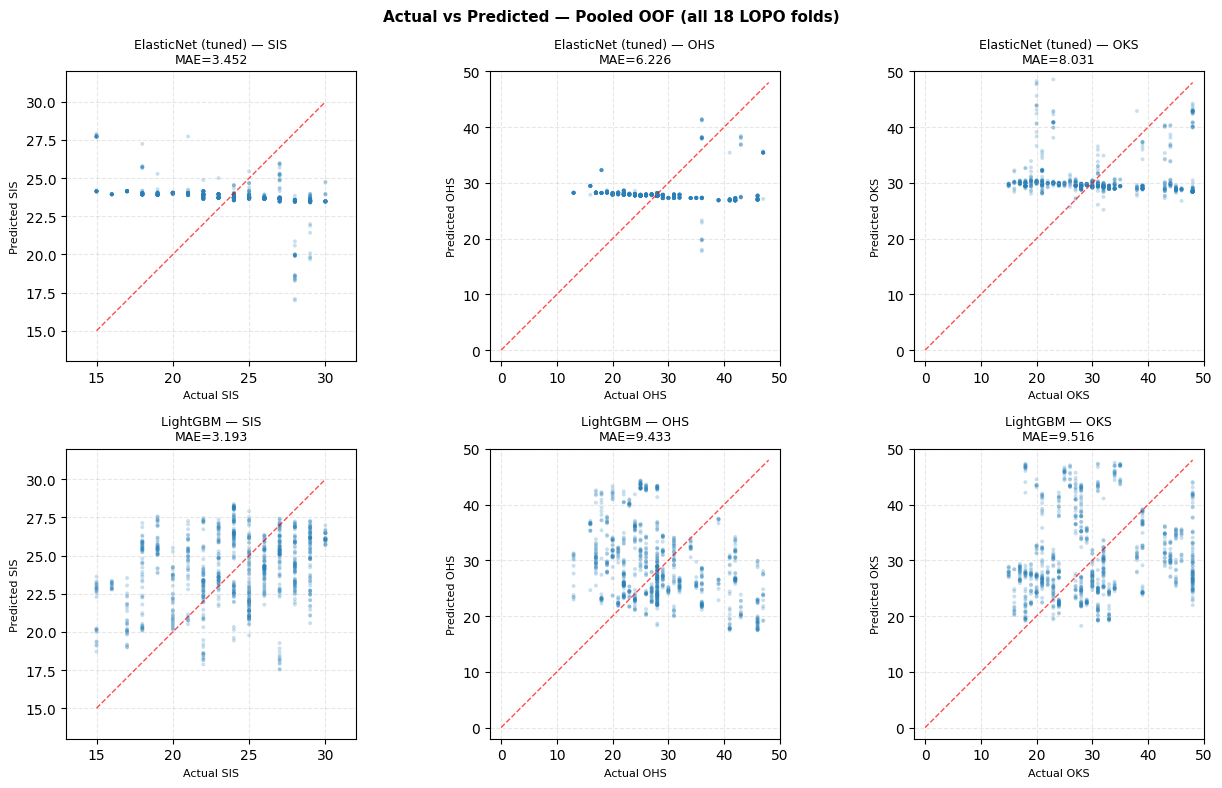

[OK] Saved -> C:\Users\Nijim\Desktop\MAISON_GITHUB\outputs\figures\oof_scatter_actual_vs_predicted.png


In [19]:
# Plot pooled out-of-fold predictions for ElasticNet and LightGBM

SCATTER_MODELS = {
    'tuned_elasticnet': 'ElasticNet (tuned)',
    'lgbm':             'LightGBM',
}
TARGET_RANGES = {
    TARGET_SIS: (15, 30, 'SIS'),
    TARGET_OHS: (0,  48, 'OHS'),
    TARGET_OKS: (0,  48, 'OKS'),
}

fig, axes = plt.subplots(len(SCATTER_MODELS), len(TARGET_RANGES),
                          figsize=(13, 8))
fig.suptitle('Actual vs Predicted — Pooled OOF (all 18 LOPO folds)',
             fontsize=11, fontweight='bold')

for row_i, (m_tag, m_label) in enumerate(SCATTER_MODELS.items()):
    for col_i, (target, (tmin, tmax, tlabel)) in enumerate(TARGET_RANGES.items()):
        ax = axes[row_i][col_i]
        key = f'{m_tag}_{target}'
        if key not in oof_pred_store or not oof_pred_store[key]['y_true']:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        y_true = np.array(oof_pred_store[key]['y_true'])
        y_pred_oof = np.array(oof_pred_store[key]['y_pred'])
        ax.scatter(y_true, y_pred_oof, alpha=0.25, s=8,
                   color='#2980b9', edgecolors='none')
        diag = np.linspace(tmin, tmax, 100)
        ax.plot(diag, diag, 'r--', linewidth=1, alpha=0.7, label='perfect')
        mae_all = np.mean(np.abs(y_true - y_pred_oof))
        ax.set_xlabel(f'Actual {tlabel}', fontsize=8)
        ax.set_ylabel(f'Predicted {tlabel}', fontsize=8)
        ax.set_title(f'{m_label} — {tlabel}\nMAE={mae_all:.3f}', fontsize=9)
        ax.set_xlim(tmin - 2, tmax + 2)
        ax.set_ylim(tmin - 2, tmax + 2)
        ax.set_aspect('equal', 'box')
        ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
scatter_path = FIGURES_DIR / 'oof_scatter_actual_vs_predicted.png'
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print(f'[OK] Saved -> {scatter_path}')

### ElasticNet note

ElasticNet combines L1 and L2 regularisation.

That makes it a useful choice here because the final feature space is large and highly correlated.  
Compared with Ridge, it can both stabilise the model and remove weak features.

### Ridge vs ElasticNet

Both linear models were tested under the same LOPO-CV setup.

ElasticNet performs clearly better than Ridge on SIS, OHS, and OKS.  
This suggests that adding L1 regularisation helps by reducing the effect of weak or redundant rolling features.


### Delta-target analysis

I also test a delta version of the task, where the target is the change from each participant’s own baseline instead of the absolute score.

This helps reduce participant mean-shift and makes it easier to see whether the models are learning change over time rather than absolute score level.

The features stay the same, and only the target changes.


In [20]:

# Build delta targets using each participant's earliest clinical block as baseline

_raw_clin = df_raw[[PARTICIPANT_COL, DATE_COL, CLINICAL_TS_COL]].copy()
_raw_clin[CLINICAL_TS_COL] = pd.to_datetime(_raw_clin[CLINICAL_TS_COL])

# Add clinical timestamp back so the earliest block can be identified
_df_clin = (
    df_model[[PARTICIPANT_COL, DATE_COL, TARGET_SIS, TARGET_OHS, TARGET_OKS]]
    .merge(_raw_clin, on=[PARTICIPANT_COL, DATE_COL], how='left')
)

# Take the first clinical block for each participant
_baselines = (
    _df_clin
    .sort_values([PARTICIPANT_COL, CLINICAL_TS_COL])
    .groupby(PARTICIPANT_COL, sort=False)[[TARGET_SIS, TARGET_OHS, TARGET_OKS]]
    .first()
    .rename(columns={TARGET_SIS: 'baseline_sis', TARGET_OHS: 'baseline_ohs',
                     TARGET_OKS: 'baseline_oks'})
    .reset_index()
)

print("Participant baselines (SIS / OHS / OKS at earliest clinical block):")
print(_baselines.to_string(index=False))

TARGET_SIS_DELTA = 'sis_delta'
TARGET_OHS_DELTA = 'ohs_delta'
TARGET_OKS_DELTA = 'oks_delta'

df_model_delta = (
    df_model.copy()
    .merge(_baselines, on=PARTICIPANT_COL, how='left')
)
df_model_delta[TARGET_SIS_DELTA] = (
    df_model_delta[TARGET_SIS] - df_model_delta['baseline_sis']
).astype(float)
df_model_delta[TARGET_OHS_DELTA] = (
    df_model_delta[TARGET_OHS] - df_model_delta['baseline_ohs']
).astype(float)
df_model_delta[TARGET_OKS_DELTA] = (
    df_model_delta[TARGET_OKS] - df_model_delta['baseline_oks']
).astype(float)
df_model_delta = df_model_delta.drop(columns=['baseline_sis', 'baseline_ohs', 'baseline_oks'])

print()
for _dtgt in [TARGET_SIS_DELTA, TARGET_OHS_DELTA, TARGET_OKS_DELTA]:
    _rng = df_model_delta[_dtgt]
    print(f"  {_dtgt}: min={_rng.min():.1f}  max={_rng.max():.1f}  "
          f"mean={_rng.mean():.2f}  std={_rng.std():.2f}  n_unique={_rng.nunique()}")

print(f"\n[OK] df_model_delta ready: {df_model_delta.shape}")

Participant baselines (SIS / OHS / OKS at earliest clinical block):
 participant  baseline_sis  baseline_ohs  baseline_oks
           1            25            25            31
           2            18            18            39
           3            26            28            48
           4            26            41            23
           5            28            36            44
           6            26            42            39
           7            24            35            31
           8            23            24            24
           9            25            19            21
          10            19            19            26
          11            15            47            48
          12            29            31            16
          13            22            28            39
          14            25            27            19
          15            17            28            19
          16            28            28            

In [21]:
# Run the same LOPO pipeline again, but with delta targets

DELTA_SPECS = [
    # (tag, model_class, model_kwargs, param_grid, selector)
    ('tuned_ridge',
     Ridge,
     dict(),
     PARAM_GRID_RIDGE,
     None),
    ('tuned_elasticnet',
     ElasticNet,
     dict(max_iter=10000, random_state=SEED),
     PARAM_GRID_ELASTICNET,
     None),
    ('rf',
     RandomForestRegressor,
     dict(random_state=SEED, n_jobs=1),
     PARAM_GRID_RF,
     None),
    ('lgbm',
     lgb.LGBMRegressor,
     dict(random_state=SEED, verbosity=-1, n_jobs=1),
     PARAM_GRID_LGB,
     None),
]

logo_d    = LeaveOneGroupOut()
groups_d  = df_model_delta[PARTICIPANT_COL].values
n_folds_d = len(df_model_delta[PARTICIPANT_COL].unique())
MAX_FOLDS_D = n_folds_d

print("=== Delta-Target LOPO-CV ===")
print(f"  Folds    : {MAX_FOLDS_D}")
print(f"  Targets  : {TARGET_SIS_DELTA}, {TARGET_OHS_DELTA}, {TARGET_OKS_DELTA}")
print(f"  Models   : {[s[0] for s in DELTA_SPECS]}")
print()

delta_records = []

for fold_idx, (train_idx, test_idx) in enumerate(
        logo_d.split(df_model_delta, groups=groups_d)):

    if fold_idx >= MAX_FOLDS_D:
        break

    df_train_d = df_model_delta.iloc[train_idx].copy()
    df_test_d  = df_model_delta.iloc[test_idx].copy()

    train_pids_d   = set(df_train_d[PARTICIPANT_COL].unique())
    test_pids_d    = set(df_test_d[PARTICIPANT_COL].unique())
    held_out_pid_d = int(list(test_pids_d)[0])

    assert len(train_pids_d & test_pids_d) == 0, \
        f"Fold {fold_idx+1}: participant overlap in delta loop"

    # Merge demographics inside the fold
    df_train_dm = df_train_d.merge(df_demo, on=PARTICIPANT_COL, how='left')
    df_test_dm  = df_test_d.merge(df_demo,  on=PARTICIPANT_COL, how='left')

    # Build rolling features separately for train and test
    df_tr_d_fe = make_features(df_train_dm, windows=WINDOWS)
    df_te_d_fe = make_features(df_test_dm,  windows=WINDOWS)

    n_inner_d   = min(len(train_pids_d), 5)
    inner_cv_d  = GroupKFold(n_splits=n_inner_d)
    inner_grp_d = df_tr_d_fe[PARTICIPANT_COL].values

    fold_rec_d = {
        'fold'         : fold_idx + 1,
        'held_out_pid' : held_out_pid_d,
    }

    print(f"  Fold {fold_idx+1:02d}/{MAX_FOLDS_D} | held-out P{held_out_pid_d:02d}")

    # Naive mean baseline for delta targets
    for dtgt in [TARGET_SIS_DELTA, TARGET_OHS_DELTA, TARGET_OKS_DELTA]:
        train_delta_mean = float(df_train_dm[dtgt].mean())
        y_te_d_vals = df_test_dm[dtgt].values
        y_pred_d_bl = np.full(len(y_te_d_vals), train_delta_mean)
        mae_d_bl = mean_absolute_error(y_te_d_vals, y_pred_d_bl)
        r2_d_bl  = r2_score(y_te_d_vals, y_pred_d_bl)
        fold_rec_d[f'naive_mean_mae_{dtgt}'] = round(mae_d_bl, 4)
        fold_rec_d[f'naive_mean_r2_{dtgt}']  = round(r2_d_bl,  4)
        print(f"    -> [{dtgt}] naive_mean          "
              f"MAE={mae_d_bl:.3f}  R2={r2_d_bl:.3f}")

    for model_tag, model_cls, model_kwargs, param_grid, selector in DELTA_SPECS:
        for dtgt in [TARGET_SIS_DELTA, TARGET_OHS_DELTA, TARGET_OKS_DELTA]:
            estimator = model_cls(**model_kwargs)
            pipe = build_model_pipeline(estimator, num_cols=ALL_NUM_COLS)
            search = GridSearchCV(
                pipe, param_grid,
                cv=inner_cv_d,
                scoring='neg_mean_absolute_error',
                refit=True, n_jobs=-1,
            )
            search.fit(
                df_tr_d_fe[FEAT_COLS_ROLLED],
                df_tr_d_fe[dtgt],
                groups=inner_grp_d,
            )
            y_pred_d = search.predict(df_te_d_fe[FEAT_COLS_ROLLED])

            mae_d = mean_absolute_error(df_te_d_fe[dtgt], y_pred_d)
            r2_d  = r2_score(df_te_d_fe[dtgt], y_pred_d)
            fold_rec_d[f'{model_tag}_mae_{dtgt}']  = round(mae_d, 4)
            fold_rec_d[f'{model_tag}_r2_{dtgt}']   = round(r2_d,  4)
            print(f"    -> [{dtgt}] {model_tag:<18}  "
                  f"MAE={mae_d:.3f}  R2={r2_d:.3f}")

    delta_records.append(fold_rec_d)

print()
print(f"[OK] {len(delta_records)}/{MAX_FOLDS_D} delta folds completed")

=== Delta-Target LOPO-CV ===
  Folds    : 18
  Targets  : sis_delta, ohs_delta, oks_delta
  Models   : ['tuned_ridge', 'tuned_elasticnet', 'rf', 'lgbm']

  Fold 01/18 | held-out P01
    -> [sis_delta] naive_mean          MAE=1.265  R2=-1.066
    -> [ohs_delta] naive_mean          MAE=2.294  R2=-3.509
    -> [oks_delta] naive_mean          MAE=5.000  R2=-0.185
    -> [sis_delta] tuned_ridge         MAE=1.743  R2=-1.772
    -> [ohs_delta] tuned_ridge         MAE=3.684  R2=-11.578
    -> [oks_delta] tuned_ridge         MAE=6.628  R2=-0.908
    -> [sis_delta] tuned_elasticnet    MAE=1.270  R2=-1.089
    -> [ohs_delta] tuned_elasticnet    MAE=2.390  R2=-3.809
    -> [oks_delta] tuned_elasticnet    MAE=5.002  R2=-0.175
    -> [sis_delta] rf                  MAE=1.533  R2=-1.924
    -> [ohs_delta] rf                  MAE=1.639  R2=-1.392
    -> [oks_delta] rf                  MAE=5.357  R2=-0.365
    -> [sis_delta] lgbm                MAE=2.144  R2=-4.062
    -> [ohs_delta] lgbm              

In [22]:
# Save delta-target results and figures

DELTA_MODEL_MAP = {
    'baseline_naive_mean' : 'naive_mean_',
    'tuned_ridge'         : 'tuned_ridge_',
    'tuned_elasticnet'    : 'tuned_elasticnet_',
    'rf'                  : 'rf_',
    'lgbm'                : 'lgbm_',
}

delta_metric_rows = []
for rec in delta_records:
    for model_name, prefix in DELTA_MODEL_MAP.items():
        for dtgt in [TARGET_SIS_DELTA, TARGET_OHS_DELTA, TARGET_OKS_DELTA]:
            mae_key = f'{prefix}mae_{dtgt}'
            r2_key  = f'{prefix}r2_{dtgt}'
            if mae_key not in rec:
                continue
            delta_metric_rows.append({
                'model'        : model_name,
                'target'       : dtgt,
                'fold'         : rec['fold'],
                'held_out_pid' : rec['held_out_pid'],
                'mae'          : rec[mae_key],
                'r2'           : rec[r2_key],
            })

df_delta_metrics = pd.DataFrame(delta_metric_rows)

# Save per-fold results
delta_per_path = TABLES_DIR / 'lopo_metrics_per_participant_delta.csv'
df_delta_metrics.to_csv(delta_per_path, index=False)

# Save summary across folds
delta_summary = (
    df_delta_metrics
    .groupby(['model', 'target'])[['mae', 'r2']]
    .agg(['mean', 'std'])
    .round(4)
)
delta_summary.columns = ['mae_mean', 'mae_std', 'r2_mean', 'r2_std']
delta_summary = delta_summary.reset_index()
delta_sum_path = TABLES_DIR / 'lopo_metrics_summary_delta.csv'
delta_summary.to_csv(delta_sum_path, index=False)

# Print summary
print("=== Delta-Target Results (mean +/- std across LOPO folds) ===")
for dtgt in [TARGET_SIS_DELTA, TARGET_OHS_DELTA, TARGET_OKS_DELTA]:
    print(f"\n  Target: {dtgt.upper()}")
    _sub = delta_summary[delta_summary['target'] == dtgt].copy()
    _sub['MAE'] = _sub.apply(
        lambda r: f"{r['mae_mean']:.3f} +/- {r['mae_std']:.3f}", axis=1)
    _sub['R2']  = _sub.apply(
        lambda r: f"{r['r2_mean']:.3f} +/- {r['r2_std']:.3f}", axis=1)
    print(_sub[['model', 'MAE', 'R2']].to_string(index=False))

# Delta comparison figures
DELTA_MODEL_ORDER  = ['tuned_ridge', 'tuned_elasticnet', 'rf', 'lgbm']
DELTA_MODEL_LABELS = {
    'tuned_ridge'      : 'Ridge\n(tuned)',
    'tuned_elasticnet' : 'Elastic\nNet',
    'rf'               : 'Random\nForest',
    'lgbm'             : 'LightGBM',
}
DELTA_PALETTE = ['#2980b9', '#16a085', '#27ae60', '#e67e22']


def _make_delta_fig(dtgt, out_path):
    _sub = (
        delta_summary[delta_summary['target'] == dtgt]
        .set_index('model')
        .reindex(DELTA_MODEL_ORDER)
        .dropna(subset=['mae_mean'])
        .reset_index()
    )
    labels = [DELTA_MODEL_LABELS[m] for m in _sub['model']]
    colors = [DELTA_PALETTE[DELTA_MODEL_ORDER.index(m)] for m in _sub['model']]
    x = np.arange(len(_sub))
    n_folds_run_d = df_delta_metrics['fold'].nunique()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    fig.suptitle(
        f'Delta-Target Comparison -- {dtgt.upper()}  '
        f'(LOPO-CV, {n_folds_run_d} folds)',
        fontsize=11, fontweight='bold',
    )
    metrics_spec = [
        (axes[0], 'mae_mean', 'mae_std', 'Mean Absolute Error', 'MAE (lower is better)'),
        (axes[1], 'r2_mean',  'r2_std',  'R2 Score',            'R2 (higher is better)'),
    ]
    for ax, metric, metric_std, title, ylabel in metrics_spec:
        std_vals = _sub[metric_std].fillna(0)
        bars = ax.bar(
            x, _sub[metric], width=0.45,
            yerr=std_vals, capsize=4,
            color=colors, edgecolor='white', linewidth=0.5,
            error_kw=dict(ecolor='#555555', elinewidth=1.2, capthick=1.2),
        )
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        if metric == 'r2_mean':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        for bar, val, err in zip(bars, _sub[metric], std_vals):
            label_y = val + err + abs(val) * 0.03 + 0.01
            ax.text(
                bar.get_x() + bar.get_width() / 2, label_y,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8,
            )
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'[OK] Saved -> {out_path}')


_make_delta_fig(TARGET_SIS_DELTA, FIGURES_DIR / 'model_comparison_sis_delta.png')
_make_delta_fig(TARGET_OHS_DELTA, FIGURES_DIR / 'model_comparison_ohs_delta.png')
_make_delta_fig(TARGET_OKS_DELTA, FIGURES_DIR / 'model_comparison_oks_delta.png')

# Check that the delta outputs were saved
for _p in [delta_per_path, delta_sum_path,
           FIGURES_DIR / 'model_comparison_sis_delta.png',
           FIGURES_DIR / 'model_comparison_ohs_delta.png',
           FIGURES_DIR / 'model_comparison_oks_delta.png']:
    assert _p.exists() and _p.stat().st_size > 0, f"Missing delta output: {_p}"
    print(f'[OK] {_p.name}: {_p.stat().st_size:,} bytes')

print()
print('[OK] All delta outputs saved.')

=== Delta-Target Results (mean +/- std across LOPO folds) ===

  Target: SIS_DELTA
              model             MAE                 R2
baseline_naive_mean 1.864 +/- 1.135   -1.315 +/- 1.053
               lgbm 2.571 +/- 1.102   -4.181 +/- 4.448
                 rf 2.282 +/- 1.035   -3.062 +/- 3.615
   tuned_elasticnet 1.856 +/- 1.197   -1.280 +/- 1.125
        tuned_ridge 3.891 +/- 2.909 -36.789 +/- 92.771

  Target: OHS_DELTA
              model             MAE                R2
baseline_naive_mean 2.855 +/- 1.896  -0.726 +/- 0.973
               lgbm 3.681 +/- 1.863  -2.760 +/- 4.030
                 rf 3.911 +/- 1.760  -3.424 +/- 4.608
   tuned_elasticnet 2.830 +/- 1.878  -0.751 +/- 1.021
        tuned_ridge 5.028 +/- 2.179 -9.363 +/- 10.324

  Target: OKS_DELTA
              model             MAE                  R2
baseline_naive_mean 3.315 +/- 2.104    -1.187 +/- 1.065
               lgbm 3.577 +/- 2.015    -1.395 +/- 1.177
                 rf 3.631 +/- 2.020    -1.570 +/- 1.2

## Statistical analysis: Friedman tests

This section uses fold-level LOPO-CV MAE values to test whether model differences are consistent across held-out participants. Friedman tests are applied separately for each target, and Kendall's W is reported as the effect-size measure.


In [23]:
# Statistical analysis: Friedman tests
# Uses existing fold-level LOPO-CV MAE results only. No model retraining.

from pathlib import Path
from scipy.stats import friedmanchisquare
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

OUTPUTS_DIR = Path("outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ABS_PER_FOLD_PATH = TABLES_DIR / "lopo_metrics_per_participant.csv"
DELTA_PER_FOLD_PATH = TABLES_DIR / "lopo_metrics_per_participant_delta.csv"

if not ABS_PER_FOLD_PATH.exists():
    raise FileNotFoundError(f"Missing file: {ABS_PER_FOLD_PATH}")

if not DELTA_PER_FOLD_PATH.exists():
    raise FileNotFoundError(f"Missing file: {DELTA_PER_FOLD_PATH}")

df_abs_fold = pd.read_csv(ABS_PER_FOLD_PATH)
df_delta_fold = pd.read_csv(DELTA_PER_FOLD_PATH)

print("[OK] Loaded fold-level MAE files")
print(f"Absolute-score file: {ABS_PER_FOLD_PATH}")
print(f"Delta-target file: {DELTA_PER_FOLD_PATH}")
print()

# ---------------------------------------------------------------------
# Labels
# ---------------------------------------------------------------------

MODEL_LABELS = {
    "baseline_naive_mean": "Naive Mean",
    "tuned_ridge": "Ridge (tuned)",
    "tuned_elasticnet": "ElasticNet",
    "rf": "Random Forest",
    "lgbm": "LightGBM",
}

ABS_TARGETS = {
    "sis": "SIS",
    "ohs": "OHS",
    "oks": "OKS",
}

DELTA_TARGETS = {
    "sis_delta": "SIS Delta",
    "ohs_delta": "OHS Delta",
    "oks_delta": "OKS Delta",
}


def run_friedman_tests(df_metrics, setting_name, target_labels, model_order):
    """
    Run a Friedman test for each target.

    The Friedman test compares paired fold-level MAE values across models.
    Kendall's W is reported as an effect-size measure:
        W = chi-square / (n_folds * (n_models - 1))
    """
    rows = []

    for target, target_label in target_labels.items():
        sub = df_metrics[df_metrics["target"] == target].copy()

        pivot = sub.pivot_table(
            index="held_out_pid",
            columns="model",
            values="mae",
            aggfunc="mean",
        )

        available_models = [model for model in model_order if model in pivot.columns]
        complete = pivot[available_models].dropna()

        n_folds = len(complete)
        n_models = len(available_models)

        if n_folds < 2 or n_models < 3:
            print(f"[WARN] Not enough complete data for Friedman test: {setting_name} / {target_label}")
            continue

        model_arrays = [complete[model].values for model in available_models]
        friedman_stat, friedman_p = friedmanchisquare(*model_arrays)
        kendall_w = friedman_stat / (n_folds * (n_models - 1))

        rows.append({
            "setting": setting_name,
            "target": target_label,
            "n_folds": n_folds,
            "n_models": n_models,
            "models_compared": ", ".join(MODEL_LABELS.get(m, m) for m in available_models),
            "friedman_chi2": friedman_stat,
            "friedman_p_value": friedman_p,
            "kendall_w": kendall_w,
        })

    return pd.DataFrame(rows)


# Absolute-score setting: Naive Mean, ElasticNet, Random Forest, LightGBM
abs_model_order = [
    "baseline_naive_mean",
    "tuned_elasticnet",
    "rf",
    "lgbm",
]

# Delta-target setting: Naive Mean, Ridge, ElasticNet, Random Forest, LightGBM
delta_model_order = [
    "baseline_naive_mean",
    "tuned_ridge",
    "tuned_elasticnet",
    "rf",
    "lgbm",
]

abs_friedman = run_friedman_tests(
    df_metrics=df_abs_fold,
    setting_name="absolute_score",
    target_labels=ABS_TARGETS,
    model_order=abs_model_order,
)

delta_friedman = run_friedman_tests(
    df_metrics=df_delta_fold,
    setting_name="delta_target",
    target_labels=DELTA_TARGETS,
    model_order=delta_model_order,
)

friedman_results = pd.concat([abs_friedman, delta_friedman], ignore_index=True)

friedman_display = friedman_results.copy()
round_cols = ["friedman_chi2", "friedman_p_value", "kendall_w"]
friedman_display[round_cols] = friedman_display[round_cols].round(4)

friedman_path = TABLES_DIR / "friedman_overall_tests.csv"
friedman_display.to_csv(friedman_path, index=False)

print("=== Friedman overall tests ===")
print(friedman_display.to_string(index=False))
print()
print(f"[OK] Saved -> {friedman_path}")


[OK] Loaded fold-level MAE files
Absolute-score file: outputs\tables\lopo_metrics_per_participant.csv
Delta-target file: outputs\tables\lopo_metrics_per_participant_delta.csv

=== Friedman overall tests ===
       setting    target  n_folds  n_models                                                models_compared  friedman_chi2  friedman_p_value  kendall_w
absolute_score       SIS       18         4                Naive Mean, ElasticNet, Random Forest, LightGBM         1.4000            0.7055     0.0259
absolute_score       OHS       18         4                Naive Mean, ElasticNet, Random Forest, LightGBM        17.1333            0.0007     0.3173
absolute_score       OKS       18         4                Naive Mean, ElasticNet, Random Forest, LightGBM         1.3333            0.7212     0.0247
  delta_target SIS Delta       18         5 Naive Mean, Ridge (tuned), ElasticNet, Random Forest, LightGBM        27.8667            0.0000     0.3870
  delta_target OHS Delta       18     

In [24]:
# Paper result plots
# This version reads the saved CSV files, so it works after kernel restart.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLES_DIR = Path("outputs/tables")
FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

summary_path = TABLES_DIR / "lopo_metrics_summary.csv"
delta_summary_path = TABLES_DIR / "lopo_metrics_summary_delta.csv"

if not summary_path.exists():
    raise FileNotFoundError(f"Missing file: {summary_path}")

if not delta_summary_path.exists():
    raise FileNotFoundError(f"Missing file: {delta_summary_path}")

summary = pd.read_csv(summary_path)
delta_summary = pd.read_csv(delta_summary_path)

TARGET_ORDER_ABS = ["sis", "ohs", "oks"]
TARGET_ORDER_DELTA = ["sis_delta", "ohs_delta", "oks_delta"]

TARGET_LABELS = {
    "sis": "SIS",
    "ohs": "OHS",
    "oks": "OKS",
}

# ---------------------------------------------------
# Figure 1: Absolute-score MAE across main models
# ---------------------------------------------------
ABS_MODEL_ORDER = [
    "baseline_naive_mean",
    "tuned_elasticnet",
    "rf",
    "lgbm",
]

ABS_MODEL_LABELS = {
    "baseline_naive_mean": "Naive Mean",
    "tuned_elasticnet": "ElasticNet",
    "rf": "Random Forest",
    "lgbm": "LightGBM",
}

x = np.arange(len(TARGET_ORDER_ABS))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, model in enumerate(ABS_MODEL_ORDER):
    values = []
    errors = []

    for target in TARGET_ORDER_ABS:
        row = summary[
            (summary["model"] == model) &
            (summary["target"] == target)
        ]

        if row.empty:
            values.append(np.nan)
            errors.append(0)
        else:
            values.append(float(row["mae_mean"].iloc[0]))
            errors.append(float(row["mae_std"].iloc[0]))

    ax.bar(
        x + (i - 1.5) * width,
        values,
        width,
        yerr=errors,
        capsize=3,
        label=ABS_MODEL_LABELS[model],
    )

ax.set_xticks(x)
ax.set_xticklabels([TARGET_LABELS[t] for t in TARGET_ORDER_ABS])
ax.set_ylabel("MAE")
ax.set_xlabel("Clinical target")
ax.set_title("Absolute-score LOPO-CV MAE")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=2)

fig.tight_layout()

out_path = FIGURES_DIR / "absolute_mae_summary.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.close(fig)

print(f"[OK] Saved -> {out_path}")


# ---------------------------------------------------
# Figure 2: Absolute-score vs delta-target MAE
# ---------------------------------------------------
COMPARE_SERIES = [
    ("baseline_naive_mean", "absolute", "Naive Mean Absolute"),
    ("baseline_naive_mean", "delta",    "Naive Mean Delta"),
    ("tuned_elasticnet",    "absolute", "ElasticNet Absolute"),
    ("tuned_elasticnet",    "delta",    "ElasticNet Delta"),
]

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (model, setting, label) in enumerate(COMPARE_SERIES):
    values = []
    errors = []

    for abs_target, delta_target in zip(TARGET_ORDER_ABS, TARGET_ORDER_DELTA):
        if setting == "absolute":
            src = summary
            target = abs_target
        else:
            src = delta_summary
            target = delta_target

        row = src[
            (src["model"] == model) &
            (src["target"] == target)
        ]

        if row.empty:
            values.append(np.nan)
            errors.append(0)
        else:
            values.append(float(row["mae_mean"].iloc[0]))
            errors.append(float(row["mae_std"].iloc[0]))

    ax.bar(
        x + (i - 1.5) * width,
        values,
        width,
        yerr=errors,
        capsize=3,
        label=label,
    )

ax.set_xticks(x)
ax.set_xticklabels([TARGET_LABELS[t] for t in TARGET_ORDER_ABS])
ax.set_ylabel("MAE")
ax.set_xlabel("Clinical target")
ax.set_title("Absolute-score vs delta-target MAE")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=2)

fig.tight_layout()

out_path = FIGURES_DIR / "absolute_vs_delta_mae.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.close(fig)

print(f"[OK] Saved -> {out_path}")

[OK] Saved -> outputs\figures\absolute_mae_summary.png
[OK] Saved -> outputs\figures\absolute_vs_delta_mae.png


### Delta vs absolute targets

The delta-target version gives lower errors than the absolute-target version for all models and all three targets.

This suggests that participant mean-shift is one of the main reasons the absolute-score task is difficult. Once the baseline difference is removed, the prediction task focuses more directly on score change.

ElasticNet remains close to the Naive Mean Delta baseline, so the delta-target results should be interpreted mainly as evidence of participant mean-shift rather than as strong evidence of within-participant dynamics learned from sensors.


SHAP fold: P1 held out | train=952 rows | test=56 rows

SHAP Analysis: SIS
[OK] Saved -> outputs\figures\shap_summary_sis.png

  Modality importance (sum of mean|SHAP|) -- SIS:
    acceleration  :  2.8585  ##############################
    step          :  2.0477  #####################
    sleep         :  1.4960  ###############
    motion        :  0.5422  #####
    heartrate     :  0.4830  #####
    demographics  :  0.3921  ####
    position      :  0.1255  #


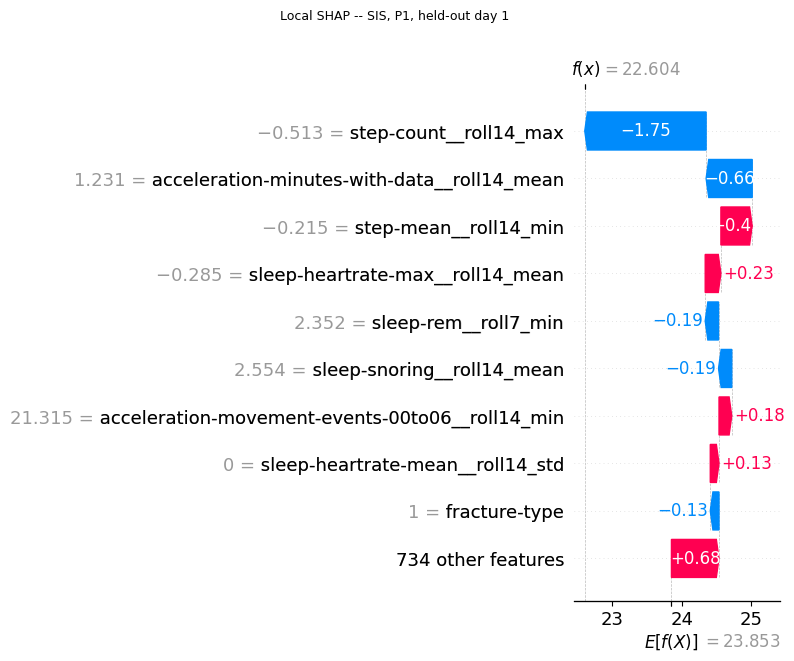

  [OK] Local explanation 1/3 shown inline


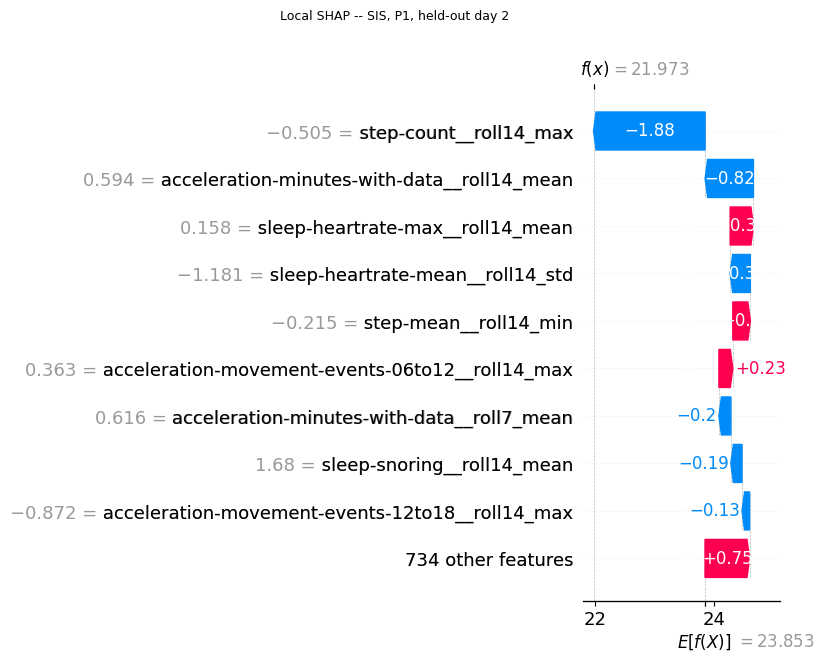

  [OK] Local explanation 2/3 shown inline


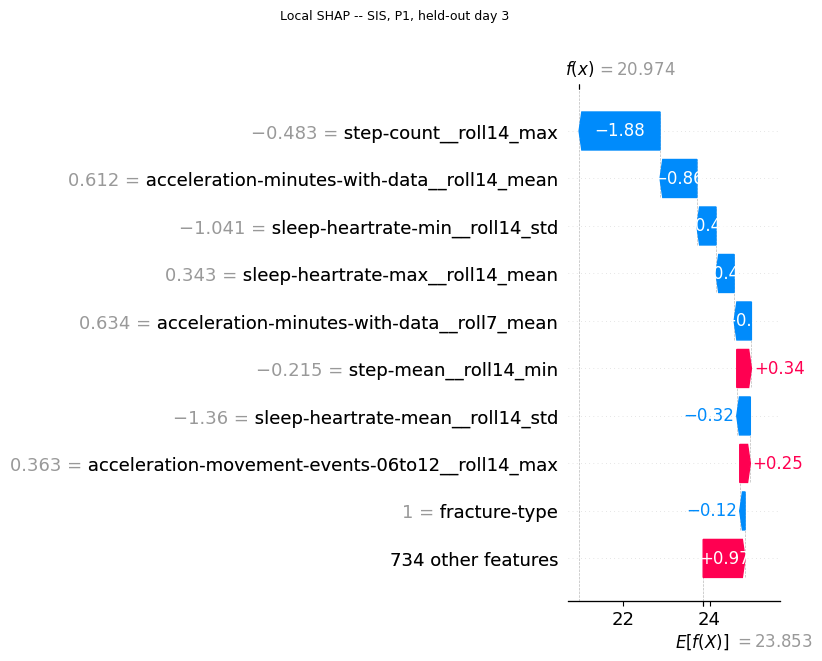

  [OK] Local explanation 3/3 shown inline

SHAP Analysis: OHS
[OK] Saved -> outputs\figures\shap_summary_ohs.png

  Modality importance (sum of mean|SHAP|) -- OHS:
    sleep         :  7.9810  ##############################
    acceleration  :  3.2333  ############
    demographics  :  2.2319  ########
    motion        :  1.3747  #####
    heartrate     :  0.5005  #
    step          :  0.3468  #
    position      :  0.2128  #


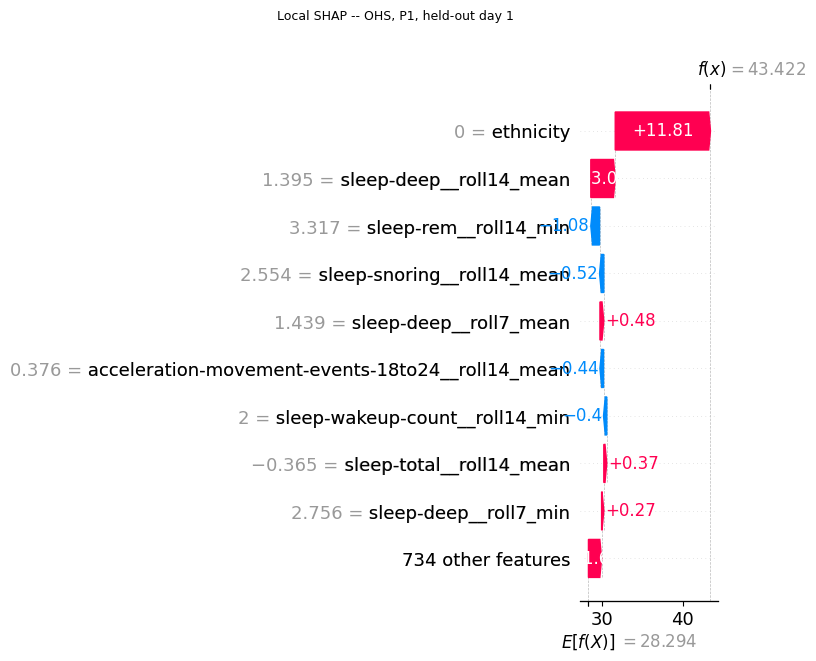

  [OK] Local explanation 1/3 shown inline


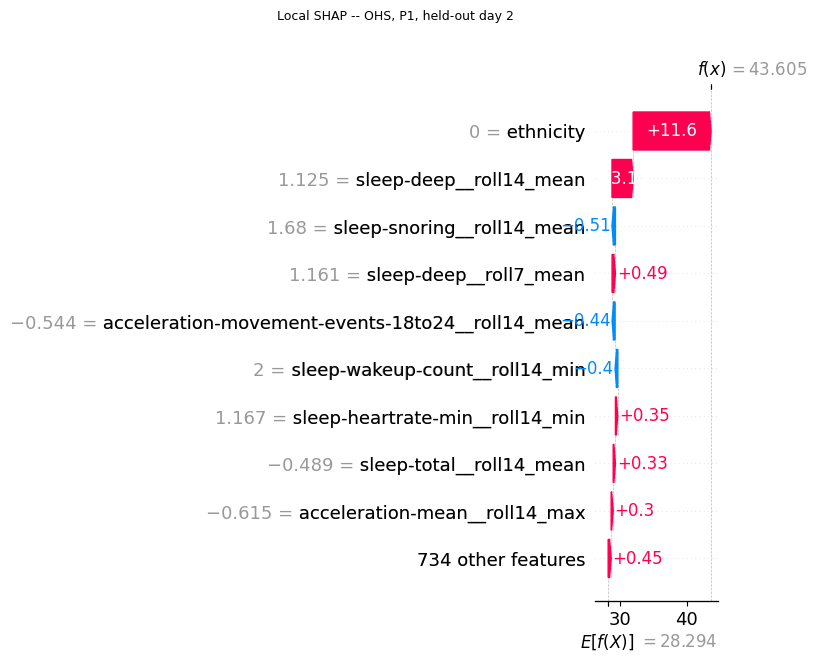

  [OK] Local explanation 2/3 shown inline


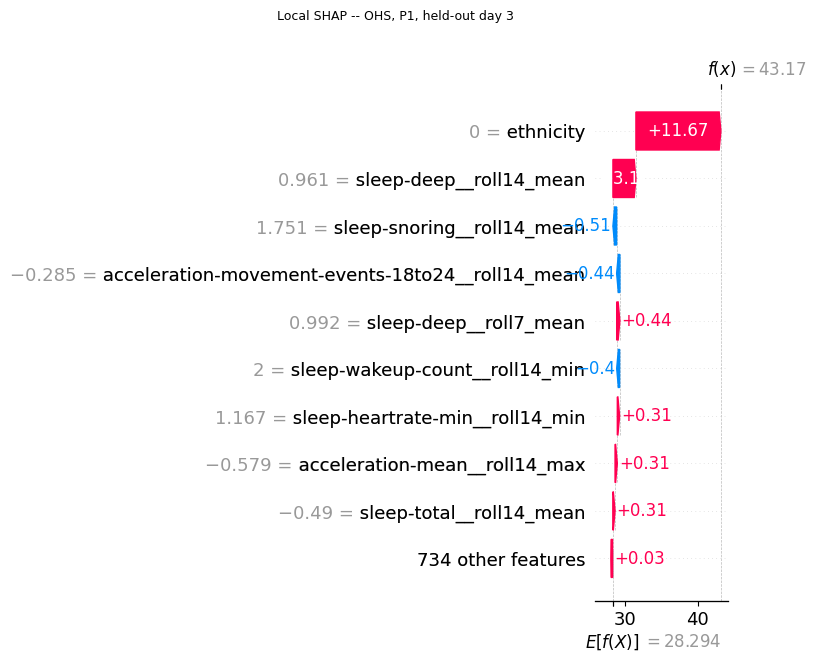

  [OK] Local explanation 3/3 shown inline

SHAP Analysis: OKS
[OK] Saved -> outputs\figures\shap_summary_oks.png

  Modality importance (sum of mean|SHAP|) -- OKS:
    motion        :  9.2403  ##############################
    sleep         :  3.8336  ############
    acceleration  :  3.2368  ##########
    demographics  :  1.2647  ####
    heartrate     :  0.6246  ##
    step          :  0.3830  #
    position      :  0.2312  #


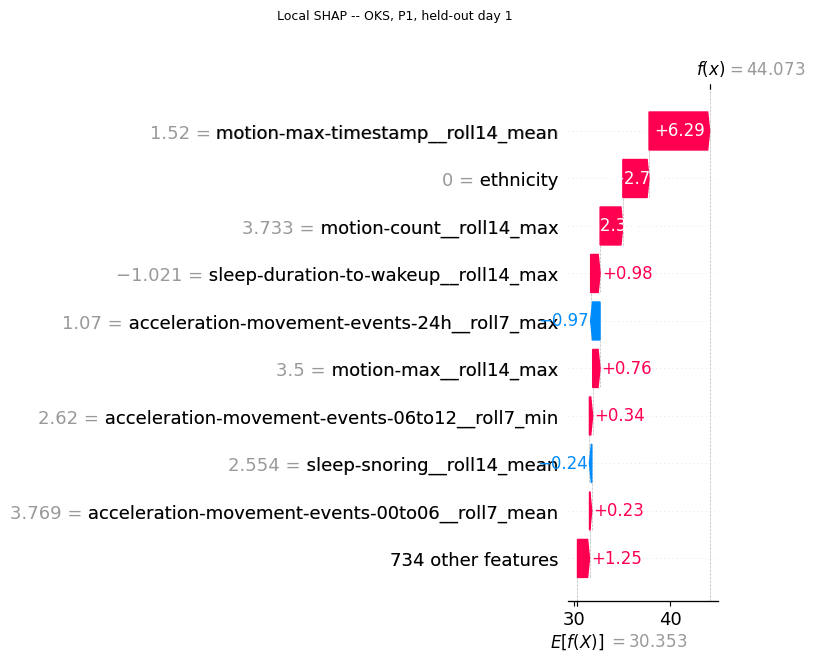

  [OK] Local explanation 1/3 shown inline


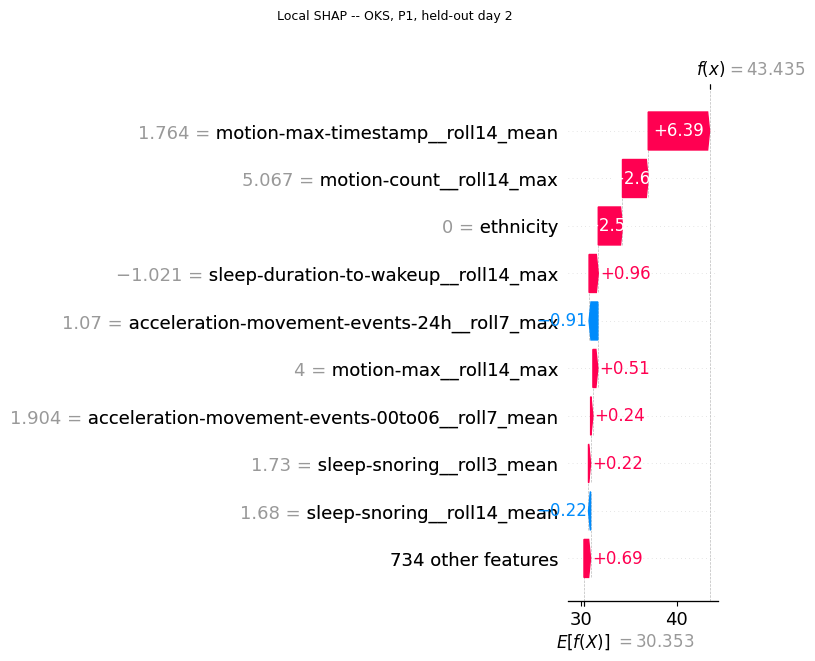

  [OK] Local explanation 2/3 shown inline


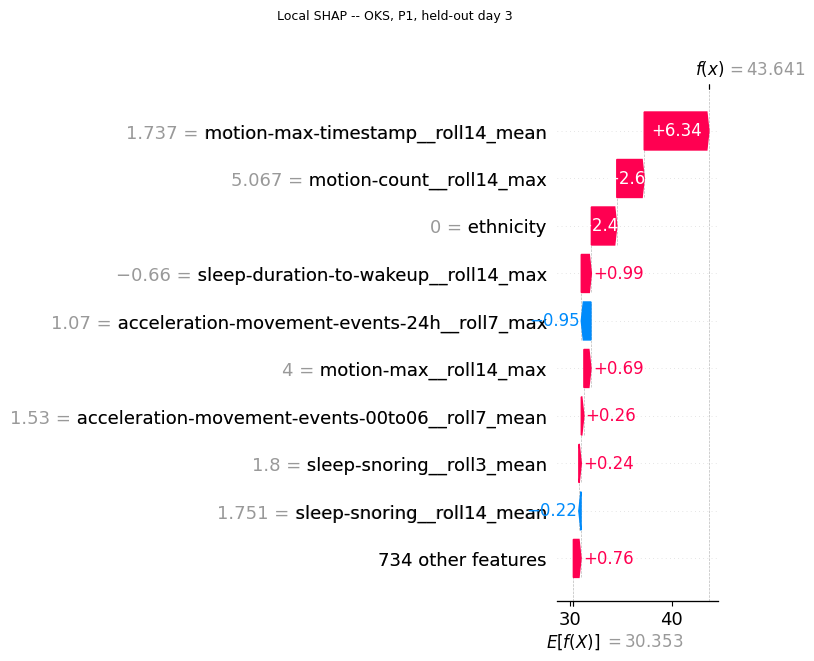

  [OK] Local explanation 3/3 shown inline
[OK] shap_summary_sis.png : 211,406 bytes
[OK] shap_summary_ohs.png : 191,459 bytes
[OK] shap_summary_oks.png : 199,073 bytes
[OK] SHAP explainability complete


In [25]:
# Run a simple SHAP analysis on one representative fold

SHAP_PID = 1   # participant held out for the SHAP example

# Split the data for the SHAP fold
shap_mask_te  = df_model[PARTICIPANT_COL] == SHAP_PID
df_shap_tr    = df_model[~shap_mask_te].copy()
df_shap_te    = df_model[ shap_mask_te].copy()

df_shap_tr    = df_shap_tr.merge(df_demo, on=PARTICIPANT_COL, how='left')
df_shap_te    = df_shap_te.merge(df_demo, on=PARTICIPANT_COL, how='left')

df_shap_tr_fe = make_features(df_shap_tr, windows=WINDOWS)
df_shap_te_fe = make_features(df_shap_te, windows=WINDOWS)

print(f"SHAP fold: P{SHAP_PID} held out | "
      f"train={df_shap_tr_fe.shape[0]} rows | test={df_shap_te_fe.shape[0]} rows")

# Group features by modality for a simple SHAP summary
MODALITY_PREFIXES = {
    'acceleration': 'acceleration',
    'heartrate'   : 'heartrate',
    'motion'      : 'motion',
    'position'    : 'position',
    'sleep'       : 'sleep',
    'step'        : 'step',
    'demographics': ('age', 'sex', 'fracture', 'relationship', 'education',
                     'work', 'ethnicity'),
}

for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
    print(f"\n{'='*60}")
    print(f"SHAP Analysis: {target.upper()}")
    print(f"{'='*60}")

    # Fit LightGBM on the SHAP training fold
    lgb_shap = lgb.LGBMRegressor(
        random_state=SEED, verbosity=-1, n_jobs=1,
        n_estimators=100,   # keep this moderate so SHAP stays manageable
    )
    pipe_shap = build_model_pipeline(lgb_shap, num_cols=ALL_NUM_COLS)
    pipe_shap.fit(df_shap_tr_fe[FEAT_COLS_ROLLED], df_shap_tr_fe[target])

    # Get transformed arrays and cleaned feature names
    preproc   = pipe_shap.named_steps['preprocess']
    X_tr_arr  = preproc.transform(df_shap_tr_fe[FEAT_COLS_ROLLED])
    X_te_arr  = preproc.transform(df_shap_te_fe[FEAT_COLS_ROLLED])

    raw_names  = preproc.get_feature_names_out()
    feat_names = [n.replace('num__', '').replace('cat__', '') for n in raw_names]

    # Compute SHAP values
    lgb_fitted = pipe_shap.named_steps['model']
    explainer  = shap.TreeExplainer(lgb_fitted)
    shap_tr    = explainer.shap_values(X_tr_arr)
    shap_te    = explainer.shap_values(X_te_arr)

    # Global summary plot
    shap.summary_plot(
        shap_tr, X_tr_arr,
        feature_names=feat_names,
        max_display=20,
        show=False,
    )
    plt.gcf().set_size_inches(10, 7)
    plt.gcf().suptitle(
        f'SHAP Summary (Global) -- {target.upper()}   '
        f'[LightGBM, P{SHAP_PID} held out, top 20 of {len(feat_names)} features]',
        fontsize=10, fontweight='bold', y=1.02,
    )
    out_path = FIGURES_DIR / f'shap_summary_{target}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'[OK] Saved -> {out_path}')

    # Modality-level importance
    shap_abs_mean = np.abs(shap_tr).mean(axis=0)
    mod_importance = {}
    for mod, prefix in MODALITY_PREFIXES.items():
        if isinstance(prefix, tuple):
            idxs = [i for i, n in enumerate(feat_names)
                    if any(n.startswith(p) for p in prefix)]
        else:
            idxs = [i for i, n in enumerate(feat_names) if n.startswith(prefix)]
        mod_importance[mod] = float(shap_abs_mean[idxs].sum()) if idxs else 0.0

    print(f"\n  Modality importance (sum of mean|SHAP|) -- {target.upper()}:")
    max_val = max(mod_importance.values()) or 1.0
    for mod, val in sorted(mod_importance.items(), key=lambda kv: -kv[1]):
        bar = '#' * max(1, int(val / max_val * 30))
        print(f"    {mod:<14}: {val:7.4f}  {bar}")

    # Local examples for a few held-out days
    n_local = min(3, len(shap_te))
    for i in range(n_local):
        exp = shap.Explanation(
            values        = shap_te[i],
            base_values   = float(explainer.expected_value),
            data          = X_te_arr[i],
            feature_names = feat_names,
        )
        shap.plots.waterfall(exp, max_display=10, show=False)
        plt.gcf().suptitle(
            f'Local SHAP -- {target.upper()}, P{SHAP_PID}, held-out day {i+1}',
            fontsize=9, y=1.01,
        )
        plt.tight_layout()
        plt.show()
        plt.close('all')
        print(f'  [OK] Local explanation {i+1}/{n_local} shown inline')

# Check that the SHAP figures were saved
for target in [TARGET_SIS, TARGET_OHS, TARGET_OKS]:
    p = FIGURES_DIR / f'shap_summary_{target}.png'
    assert p.exists(), f'SHAP summary not saved: {p}'
    sz = p.stat().st_size
    print(f'[OK] shap_summary_{target}.png : {sz:,} bytes')

print("[OK] SHAP explainability complete")

### Feature engineering

Rolling-window features are created by `make_features()`, defined earlier in the notebook.

In short, each sensor feature gets rolling mean, std, min, max, and slope over 3, 7, and 14 day windows.

### Baselines and tuned models

The LOPO loop includes two simple baselines:
- demographics-only Ridge
- naive mean predictor

It also includes the main tuned models:
- Ridge
- ElasticNet
- Random Forest
- LightGBM

All results are saved to the `outputs/tables/` folder.

## Evaluation and interpretation

This section focuses on:
- LOPO metrics
- model comparison plots
- Friedman statistical testing
- SHAP explanations
- delta-target analysis

MAE is the main metric used throughout the notebook. \(R^2\) is also reported, but it is less informative here because participant mean-shift is large.

The main tables and figures are saved automatically in the `outputs/` folder.


## Saved outputs

When the notebook finishes, it saves the main tables and figures to the `outputs/` folder.

This makes the workflow reproducible and easier to reuse in the paper, README, and GitHub repository.


## Summary

This notebook shows that wearable data contains some predictive signal for SIS, OHS, and OKS, but strict cross-participant prediction remains difficult.

Main takeaways:
- LightGBM performs best for SIS in absolute-score prediction
- ElasticNet performs best for OHS and OKS in absolute-score prediction
- improvements over the Naive Mean baseline are modest and target-dependent
- participant mean-shift is a major challenge
- delta targets reduce MAE across targets
- Friedman tests show significant overall model differences for OHS in the absolute-score setting and for all three delta targets
- the pipeline is leakage-safe and reproducible

A larger cohort would be needed to test these findings more reliably.


In [29]:
# Final output check

from pathlib import Path

print("=" * 60)
print("FINAL OUTPUT GATE")
print("=" * 60)

REQUIRED_OUTPUTS = [
    (TABLES_DIR / "lopo_metrics_summary.csv", "Absolute-score summary table"),
    (TABLES_DIR / "lopo_metrics_summary_delta.csv", "Delta-target summary table"),
    (TABLES_DIR / "lopo_metrics_per_participant.csv", "Absolute-score per-participant results"),
    (TABLES_DIR / "lopo_metrics_per_participant_delta.csv", "Delta-target per-participant results"),
    (TABLES_DIR / "friedman_overall_tests.csv", "Friedman statistical tests"),
    (FIGURES_DIR / "absolute_vs_delta_mae.png", "Absolute-vs-delta MAE figure"),
]

SUPPLEMENTARY_OUTPUTS = [
    (TABLES_DIR / "baselines.csv", "Baseline results"),
    (FIGURES_DIR / "absolute_mae_summary.png", "Absolute-score MAE figure"),
]

def safe_relative_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except ValueError:
        return str(path).replace("\\", "/")


all_ok = True

print("\nRequired outputs:")
for path, desc in REQUIRED_OUTPUTS:
    exists = path.exists()
    size = path.stat().st_size if exists else 0
    ok = exists and size > 0
    status = "[OK]" if ok else "[FAIL]"

    if not ok:
        all_ok = False

    rel = safe_relative_path(path)
    print(f"  {status} {desc}")
    print(f"       {rel} ({size:,} bytes)")

print("\nAdditional outputs (supplementary):")
for path, desc in SUPPLEMENTARY_OUTPUTS:
    exists = path.exists()
    size = path.stat().st_size if exists else 0
    status = "[OK]" if exists and size > 0 else "[MISS]"

    rel = safe_relative_path(path)
    print(f"  {status} {desc}")
    print(f"       {rel} ({size:,} bytes)")

print()

assert all_ok, (
    "One or more required outputs are missing or empty. "
    "Check the cells above for errors before uploading to GitHub."
)

print("[OK] All required outputs verified.")

FINAL OUTPUT GATE

Required outputs:
  [OK] Absolute-score summary table
       outputs/tables/lopo_metrics_summary.csv (1,095 bytes)
  [OK] Delta-target summary table
       outputs/tables/lopo_metrics_summary_delta.csv (813 bytes)
  [OK] Absolute-score per-participant results
       outputs/tables/lopo_metrics_per_participant.csv (17,446 bytes)
  [OK] Delta-target per-participant results
       outputs/tables/lopo_metrics_per_participant_delta.csv (11,354 bytes)
  [OK] Friedman statistical tests
       outputs/tables/friedman_overall_tests.csv (719 bytes)
  [OK] Absolute-vs-delta MAE figure
       outputs/figures/absolute_vs_delta_mae.png (80,330 bytes)

Additional outputs (supplementary):
  [OK] Baseline results
       outputs/tables/baselines.csv (5,691 bytes)
  [OK] Absolute-score MAE figure
       outputs/figures/absolute_mae_summary.png (74,384 bytes)

[OK] All required outputs verified.
